In [1]:
%cd /exp/jvillalba/sre24/sre24/egs/sre24-audio/fixed.v1
%ls
import os
os.environ['PATH'] = "/exp/jvillalba/hyperion/hyperion-hades/tools/sph2pipe_v2.5:"+os.environ['PATH']
print(os.environ['PATH'])
from hyperion.io import RandomAccessAudioReader, BinVADReader
import numpy as np

/exp/jvillalba/sre24/sre24/egs/sre24-audio/fixed.v1
cmd.sh*             hyp_utils@
conf/               kk.wav
core.10699          path.sh@
data/               run_001_prepare_data.sh*
datapath.sh         run_002_compute_evad.sh*
default_config.sh@  run_003_prepare_noises_rirs.sh*
exp/                run_004_prepare_xvec_train_data.sh*
global_conf/        run_005_train_xvector.sh*
/exp/jvillalba/hyperion/hyperion-hades/tools/sph2pipe_v2.5:/exp/jvillalba/anaconda/anaconda2021/envs/hades_q_py311_pt230_cu121/bin:/home/hltcoe/jvillalba/.vscode-server/cli/servers/Stable-ea1445cc7016315d0f5728f8e8b12a45dc0a7286/server/bin/remote-cli:/home/hltcoe/jvillalba/usr/bin:/cm/shared/apps/gcc/11.3.0/bin:/cm/shared/apps/uge/8.6.4/bin/lx-amd64/wrapper:/cm/shared/apps/uge/8.6.4/bin/lx-amd64:/cm/shared/apps/hltcoe:/usr/local/bin:/home/hltcoe/jvillalba/usr/bin:/exp/jvillalba/anaconda/anaconda2021/envs/hades_q_py311_pt230_cu121/bin:/exp/jvillalba/anaconda/anaconda2021/condabin:/cm/shared/apps/emacs/27.1.91/s

In [79]:
# r=RandomAccessAudioReader(recordings="data/sre_cts_superset/recordings.csv", target_sample_freq=16000)
# v=BinVADReader("csv:data/sre_cts_superset/vad.csv")
# r=RandomAccessAudioReader(recordings="data/sre16_eval_train/recordings.csv", target_sample_freq=16000)
# v=BinVADReader("csv:data/sre16_eval_train/vad.csv")
# r=RandomAccessAudioReader(recordings="data/sre21_audio_eval_test/recordings.csv")
# v=BinVADReader("scp:data/sre21_audio_eval_test/vad.csv")
# r=RandomAccessAudioReader(recordings="data/janus_eval_full_test/recordings.csv")
# v=BinVADReader("scp:data/janus_eval_full_test/vad.csv")
# r=RandomAccessAudioReader(recordings="data/janus_dev_full_test/recordings.csv")
# v=BinVADReader("scp:data/janus_dev_full_test/vad.csv")
# r=RandomAccessAudioReader(recordings="data/janus_eval_enroll/recordings.csv")
# v=BinVADReader("scp:data/janus_eval_enroll/vad.csv")
r=RandomAccessAudioReader(recordings="data/janus_dev_enroll/recordings.csv")
v=BinVADReader("scp:data/janus_dev_enroll/vad.csv")

In [80]:
import pandas as pd
# vad_table = pd.read_csv("data/sre16_eval_train/vad.csv", sep=",")
# vad_table = pd.read_csv("data/sre21_audio_eval_test/vad.csv", sep=",")
# vad_table = pd.read_csv("data/janus_eval_full_test/vad.csv", sep=",")
# vad_table = pd.read_csv("data/janus_dev_full_test/vad.csv", sep=",")
# vad_table = pd.read_csv("data/janus_eval_enroll/vad.csv", sep=",")
vad_table = pd.read_csv("data/janus_dev_enroll/vad.csv", sep=",")
vad_table.sort_values(by="prob_speech", inplace=True)
print(vad_table.iloc[:100][["id", "prob_speech"]])
keys_top = vad_table["id"].values[:100]
print(vad_table.iloc[-100:][["id", "prob_speech"]])
keys_bottom = vad_table["id"].values[-100:]
keys = keys_bottom[:50]
keys = keys_top[:50]
# keys=r.keys[:20]
# keys = r.keys[20:40]
# keys = r.keys[40:60]
# keys = r.keys[60:80]
# keys = r.keys[80:100]
print(keys)
#keys=r.keys[50:70]
x, fs = r.read(keys)
vad = v.read(keys)

                 id  prob_speech
25    janus-790.mp4    81.259370
45   janus-1467.mp4    84.057971
16    janus-383.mp4    89.712620
74   janus-2543.mp4    92.668915
27    janus-846.mp4    92.904730
..              ...          ...
14    janus-352.mp4   100.000000
15    janus-366.mp4   100.000000
98   janus-3824.mp4   100.000000
99   janus-3840.mp4   100.000000
100  janus-3884.mp4   100.000000

[100 rows x 2 columns]
                 id  prob_speech
16    janus-383.mp4    89.712620
74   janus-2543.mp4    92.668915
27    janus-846.mp4    92.904730
36   janus-1069.mp4    94.846154
0      janus-50.mp4    95.926211
..              ...          ...
98   janus-3824.mp4   100.000000
99   janus-3840.mp4   100.000000
100  janus-3884.mp4   100.000000
101  janus-3920.mp4   100.000000
1      janus-99.mp4   100.000000

[100 rows x 2 columns]
['janus-790.mp4' 'janus-1467.mp4' 'janus-383.mp4' 'janus-2543.mp4'
 'janus-846.mp4' 'janus-1069.mp4' 'janus-50.mp4' 'janus-2279.mp4'
 'janus-1042.mp4' 'janus-41

/tmp/ipykernel_222646/2819824402.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(36,3))


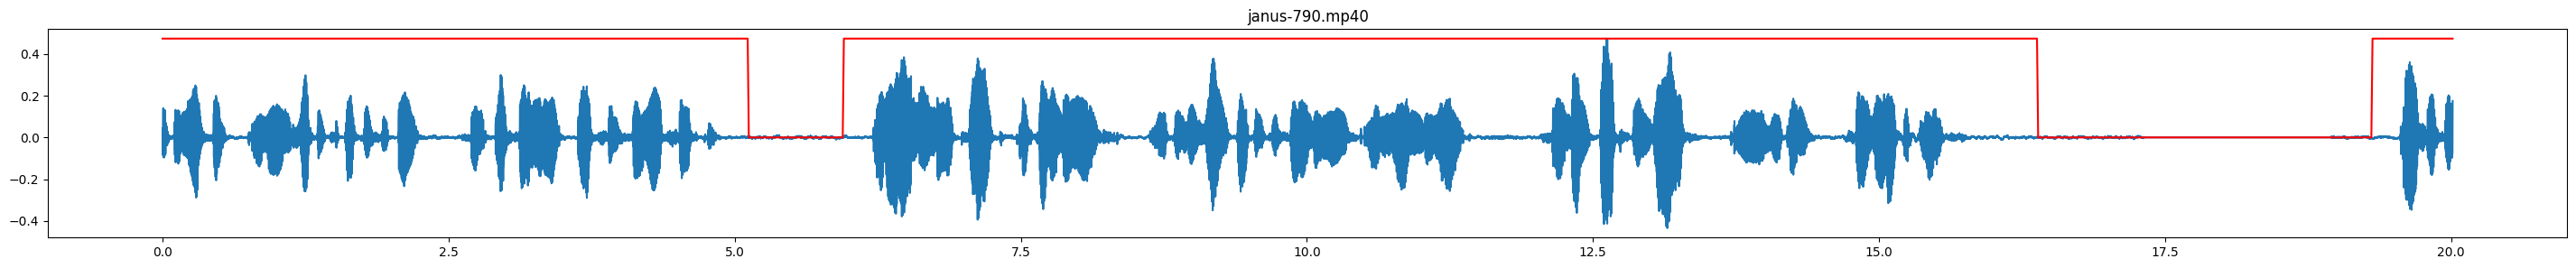

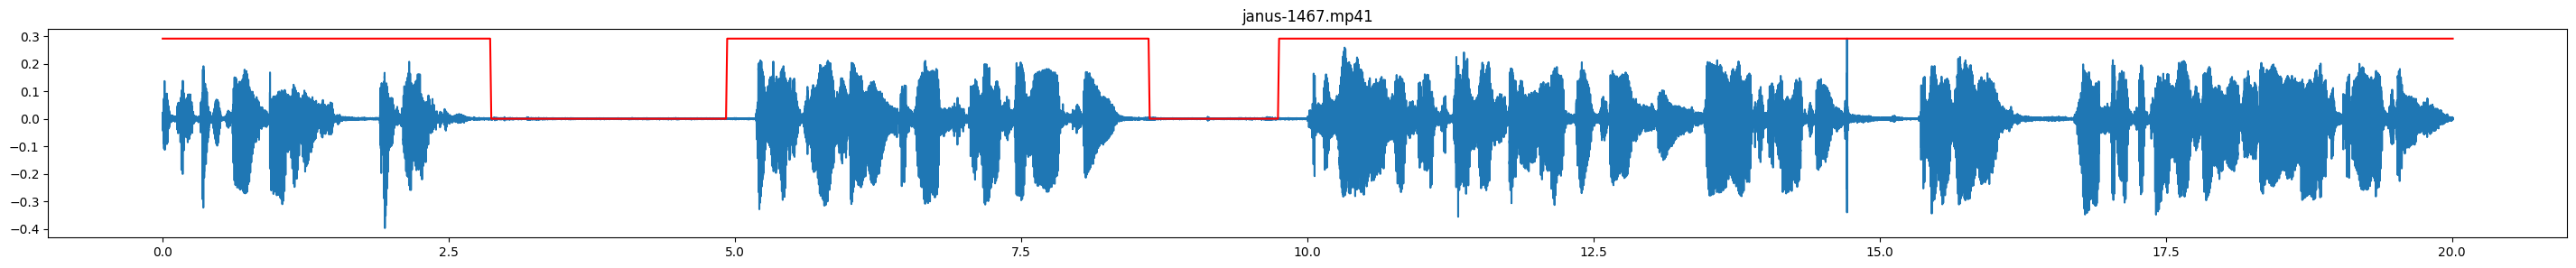

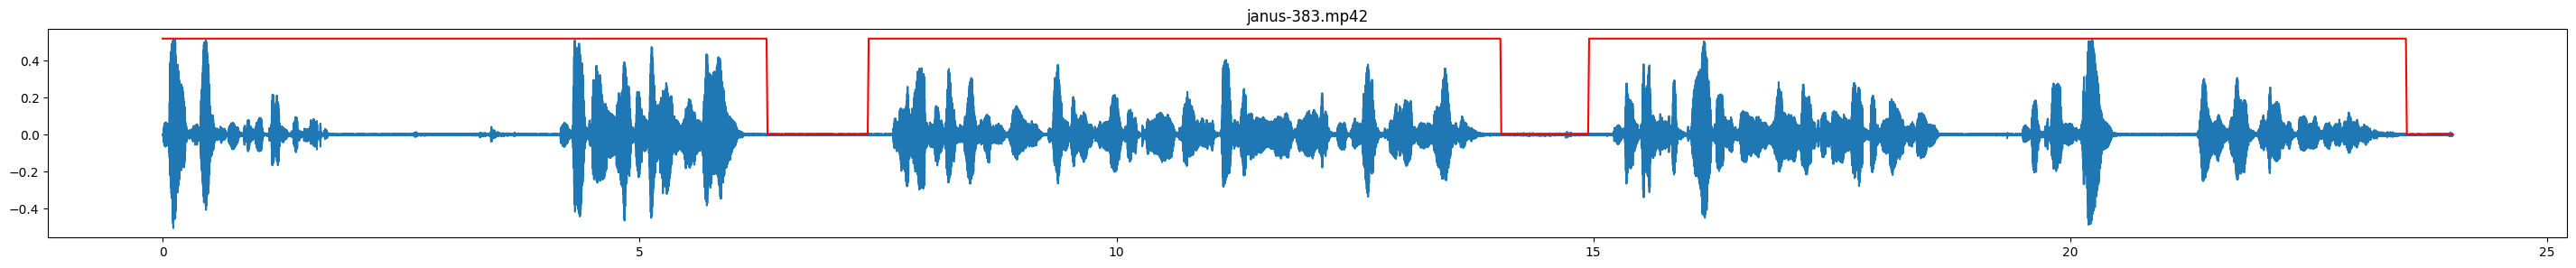

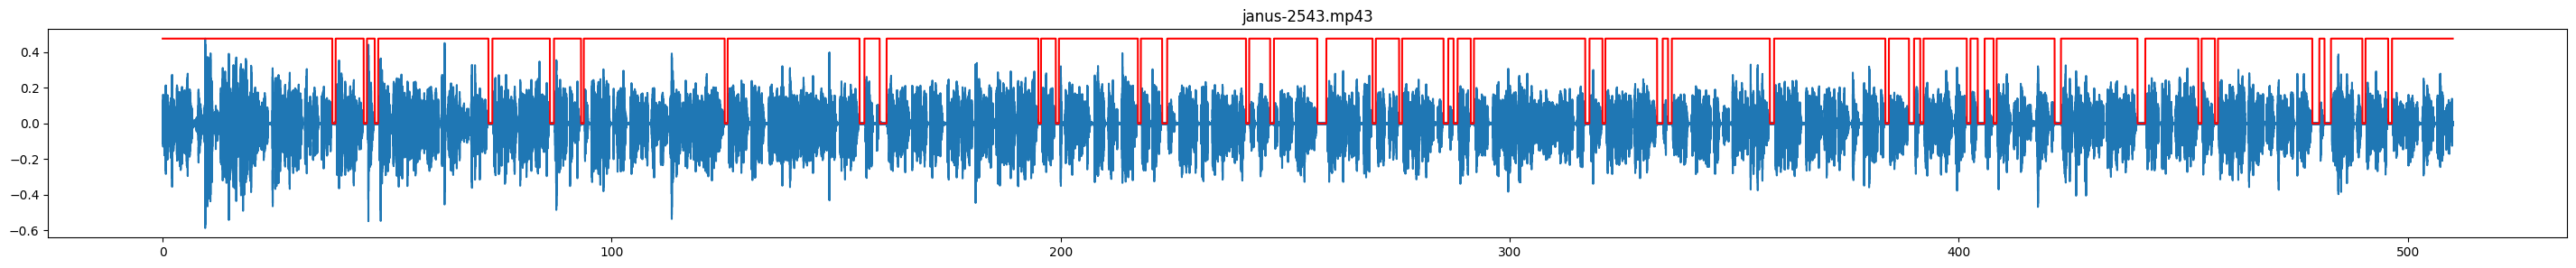

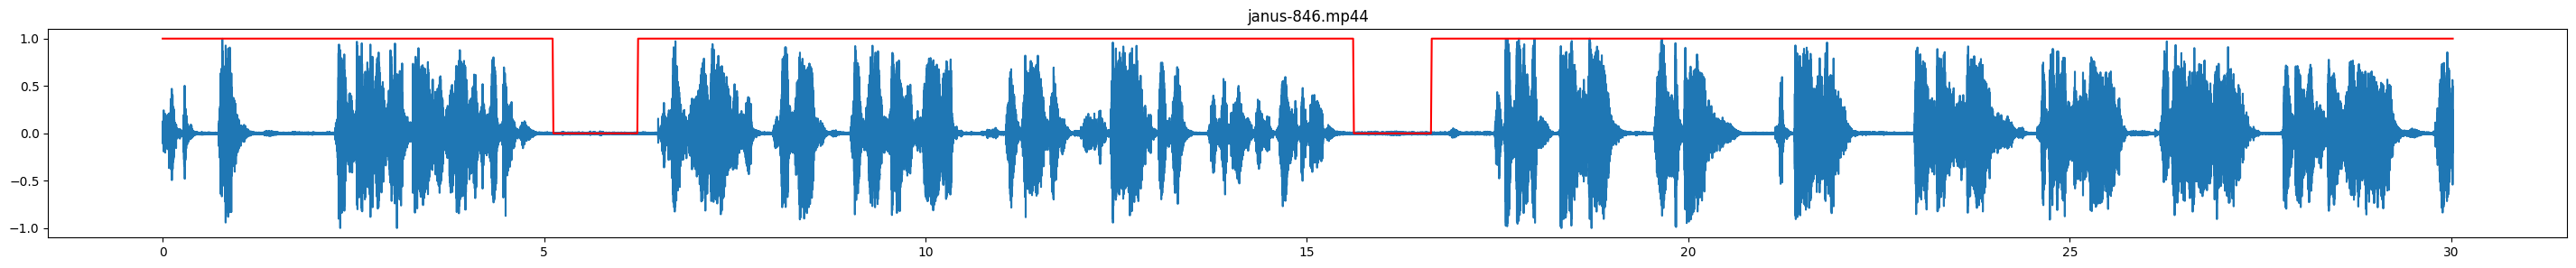

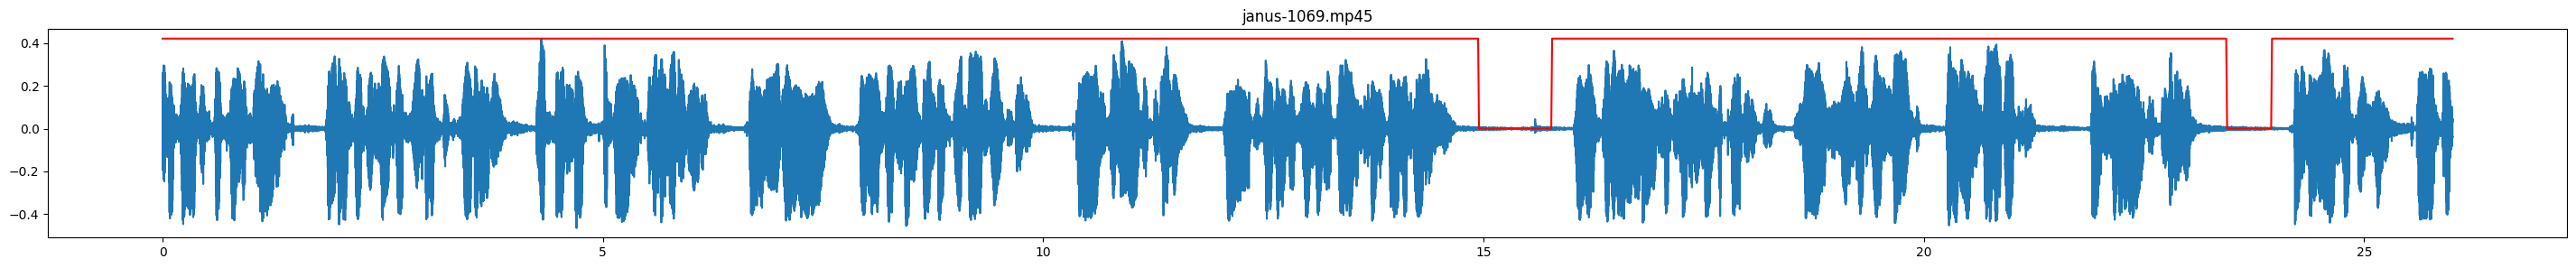

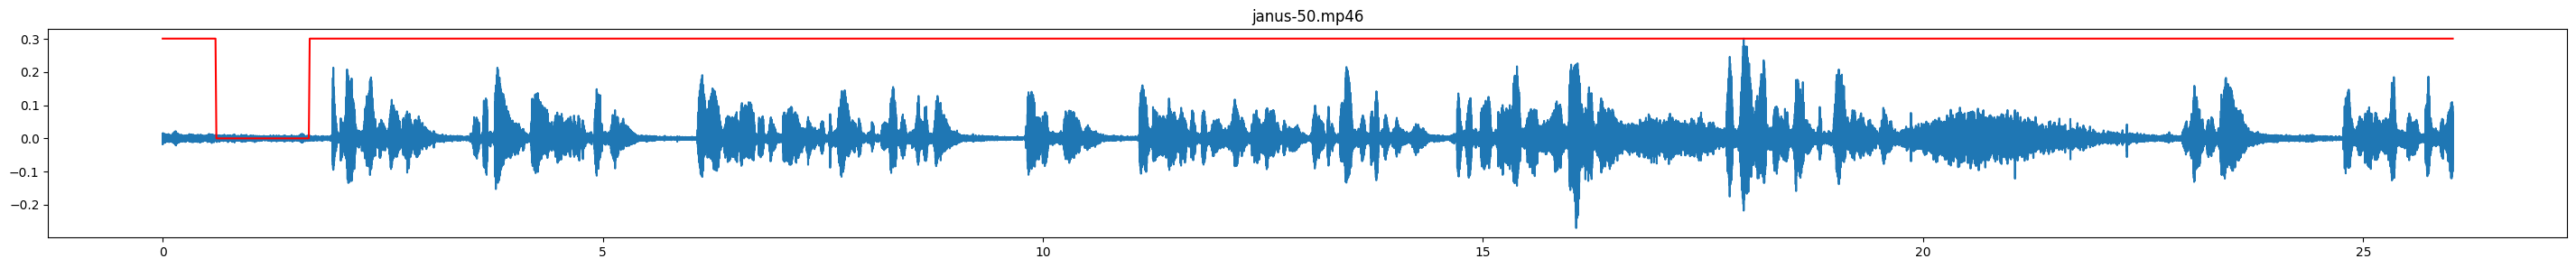

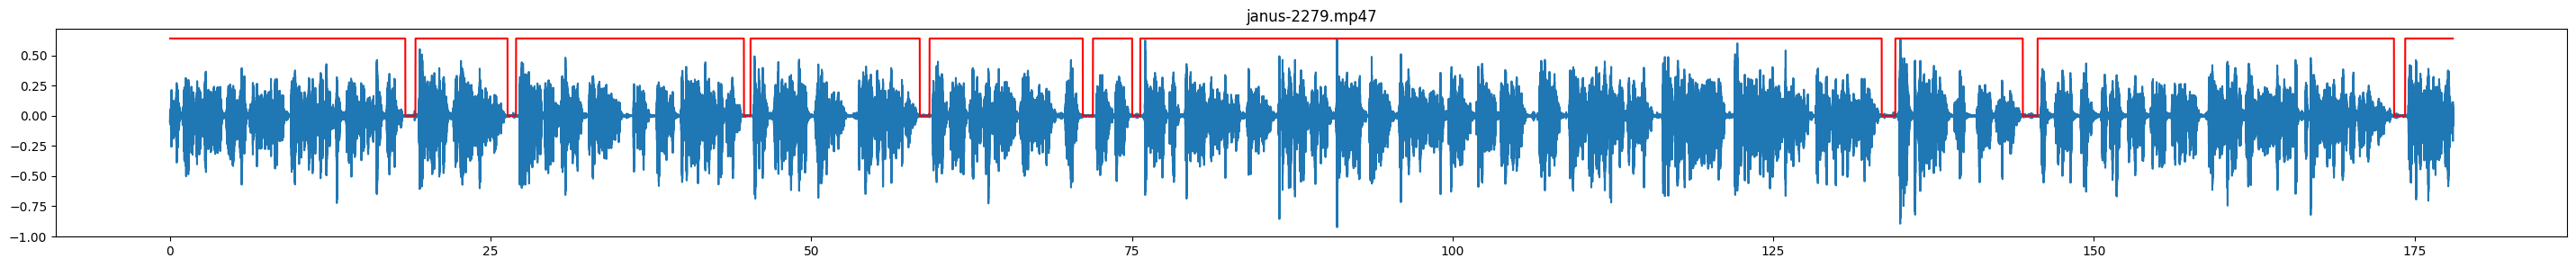

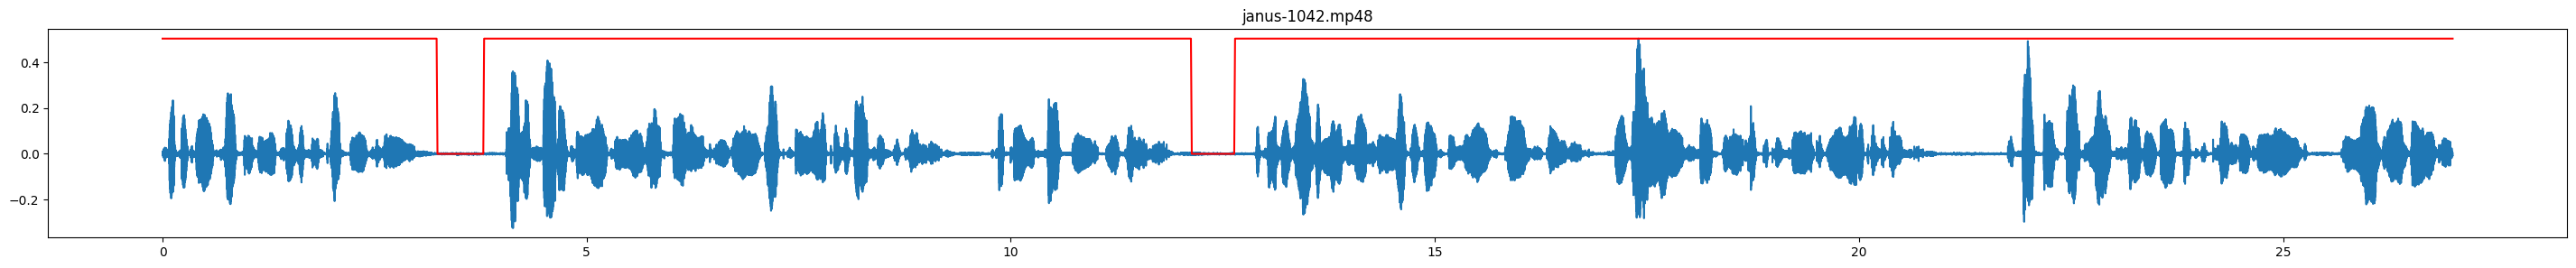

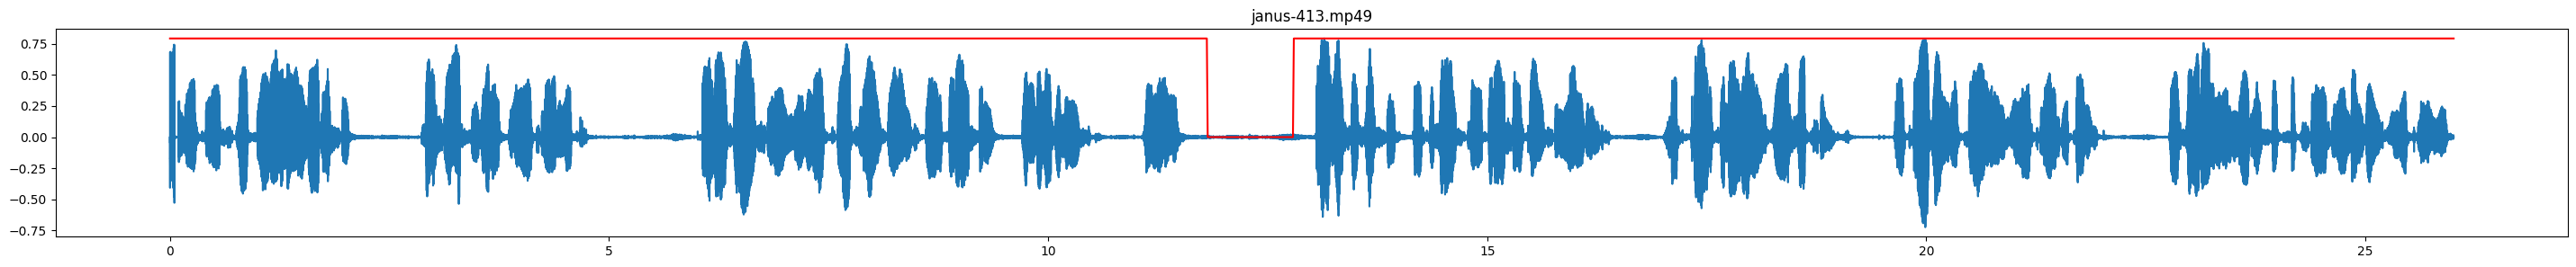

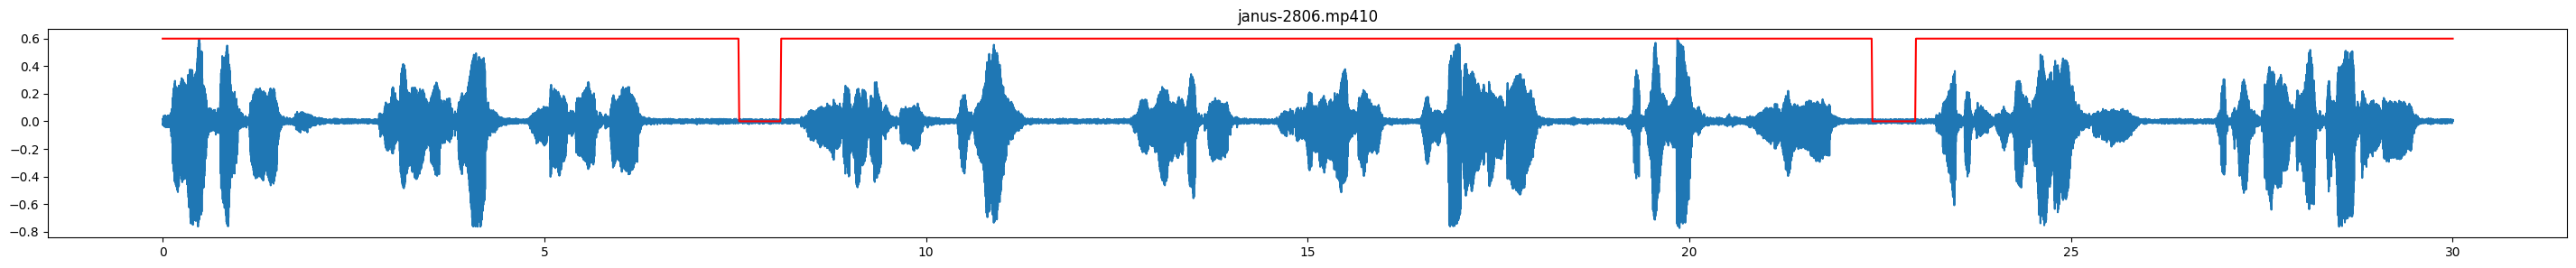

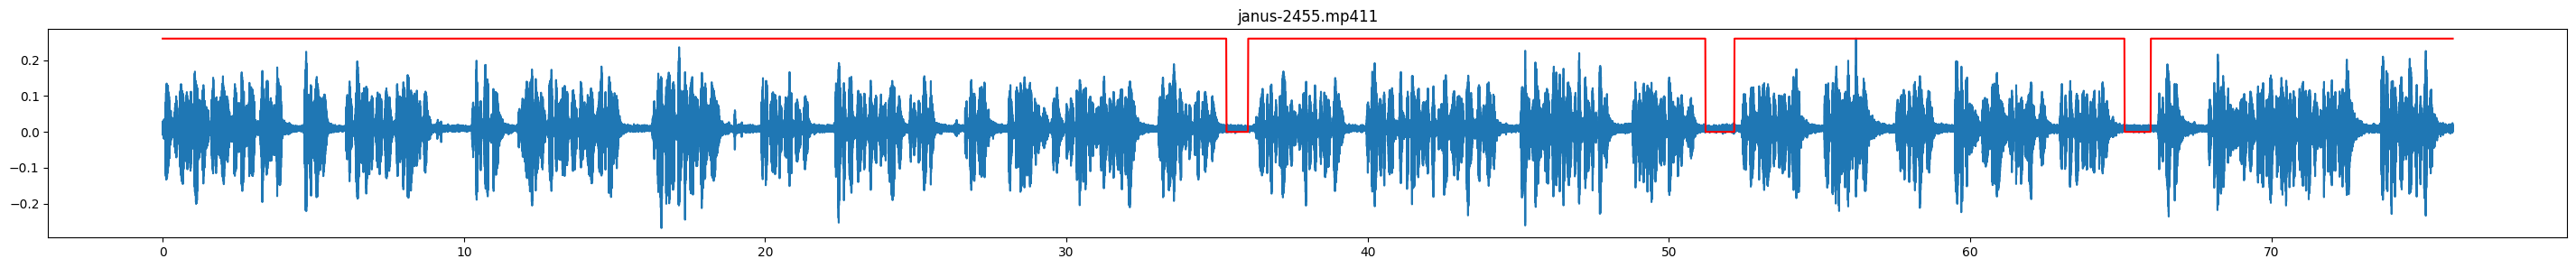

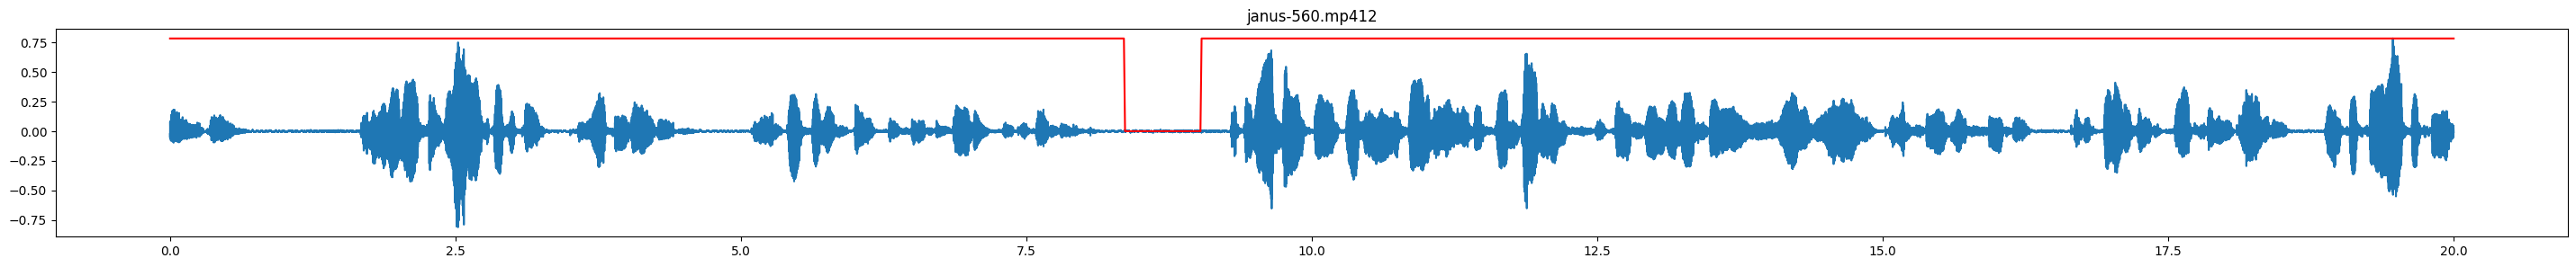

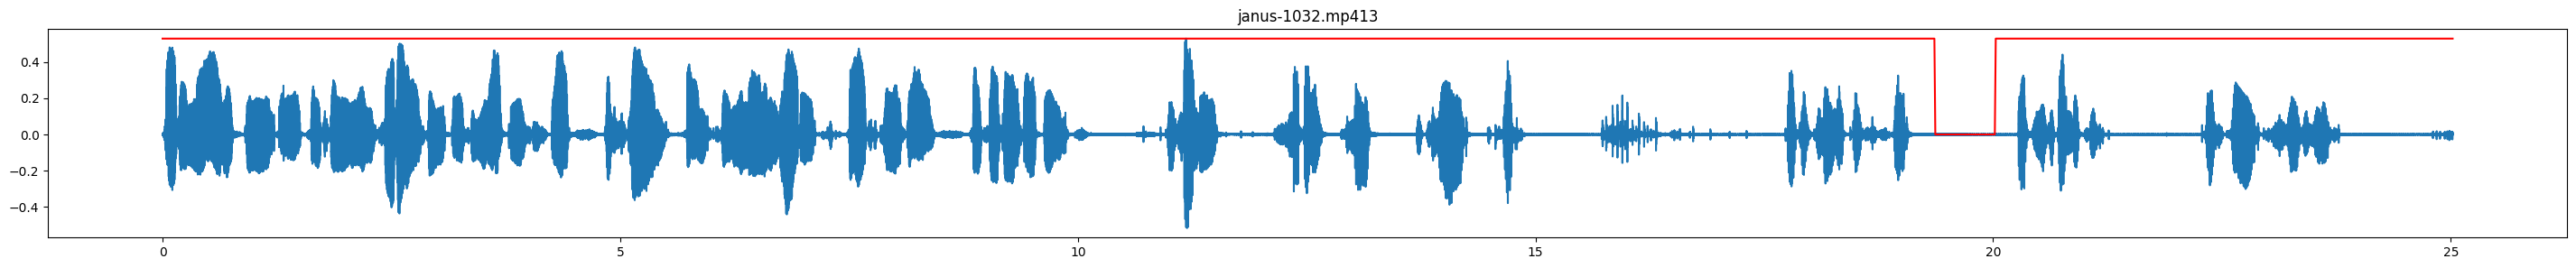

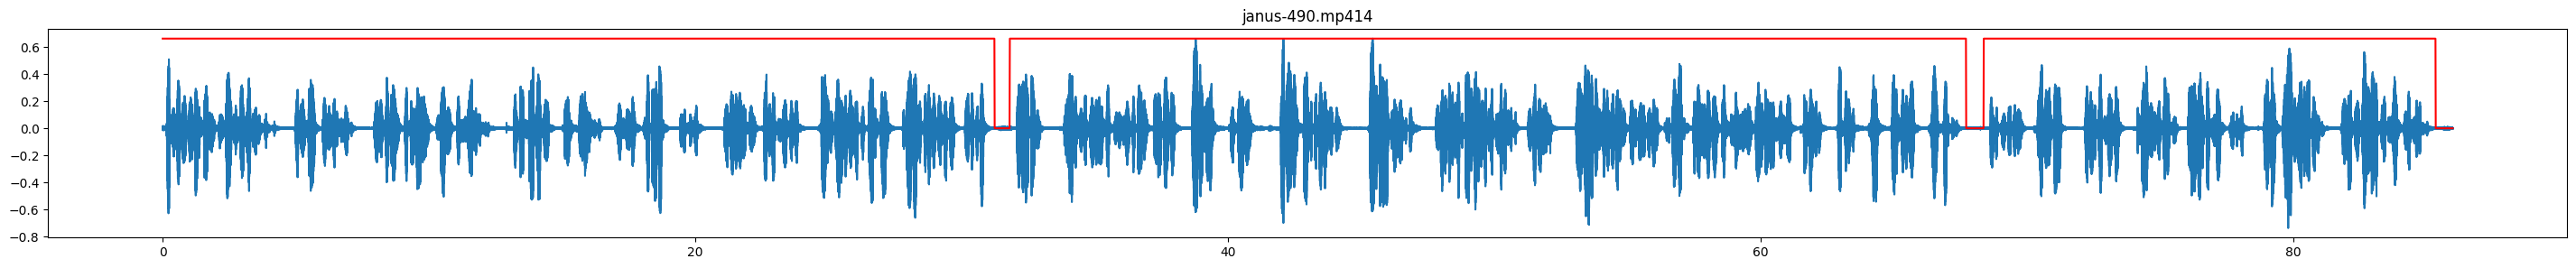

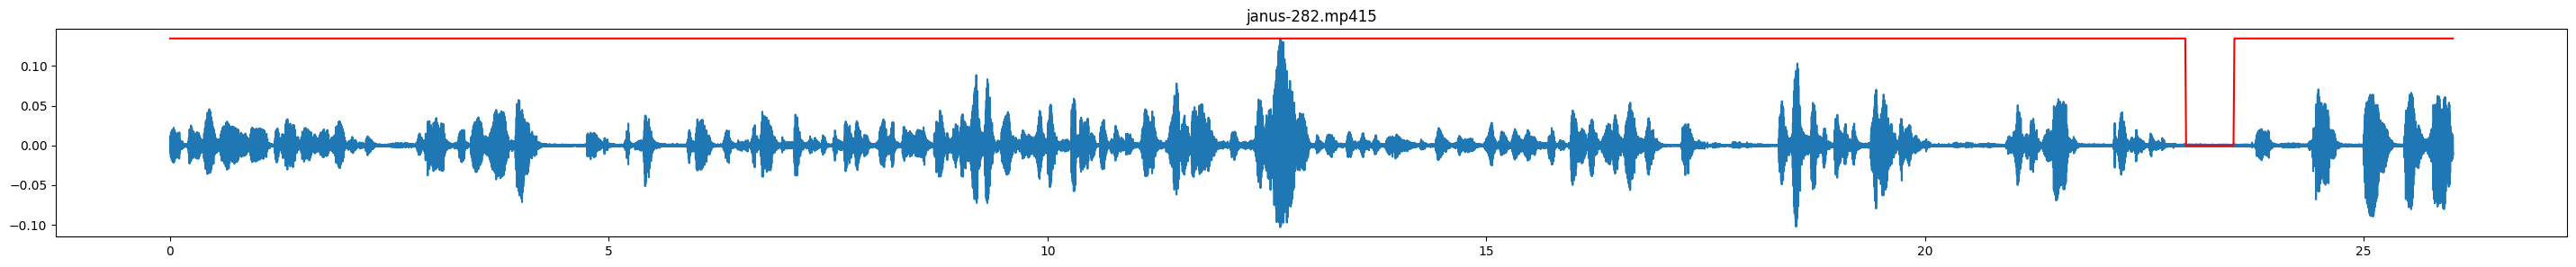

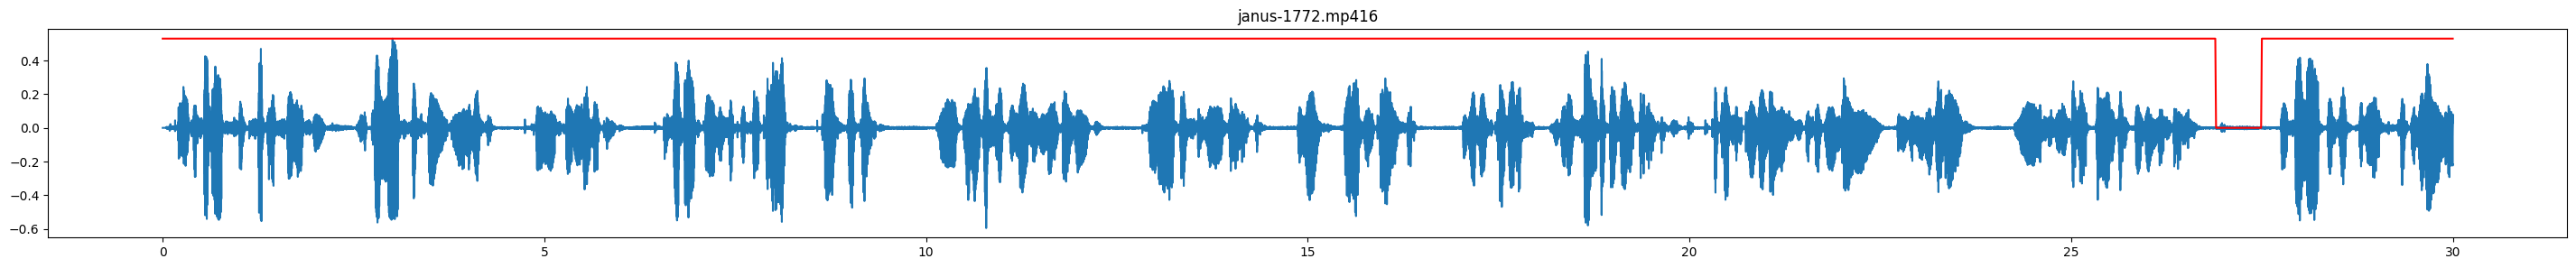

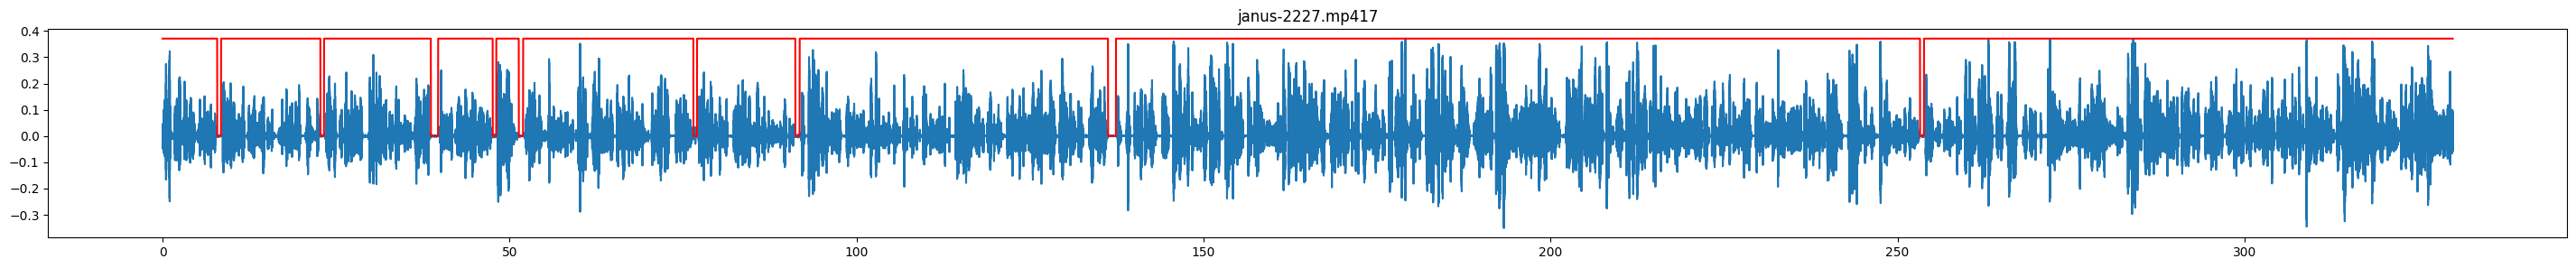

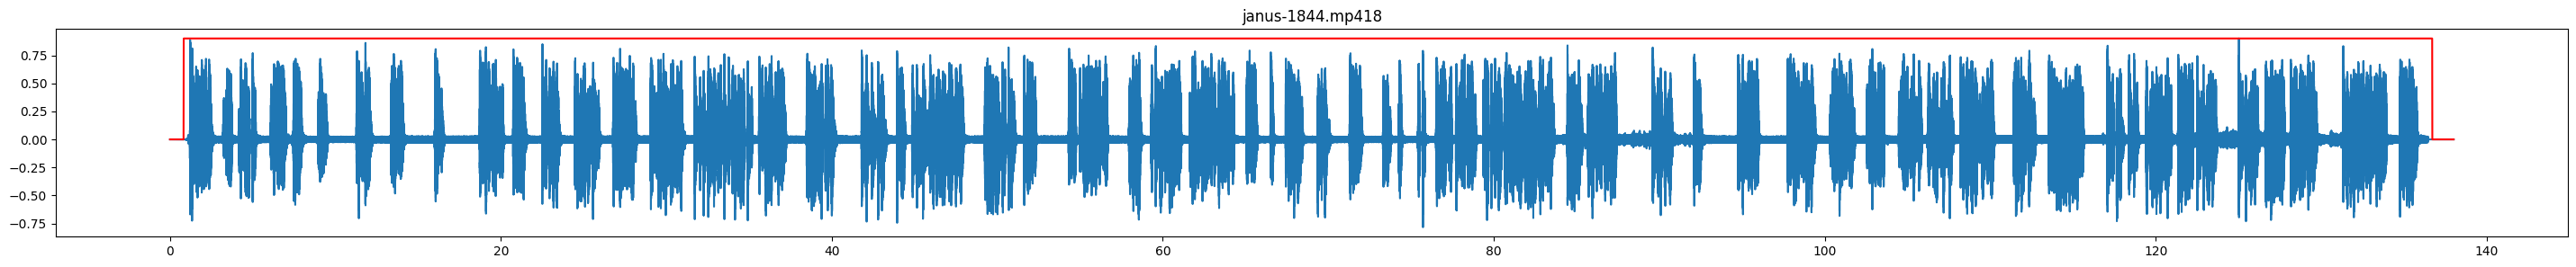

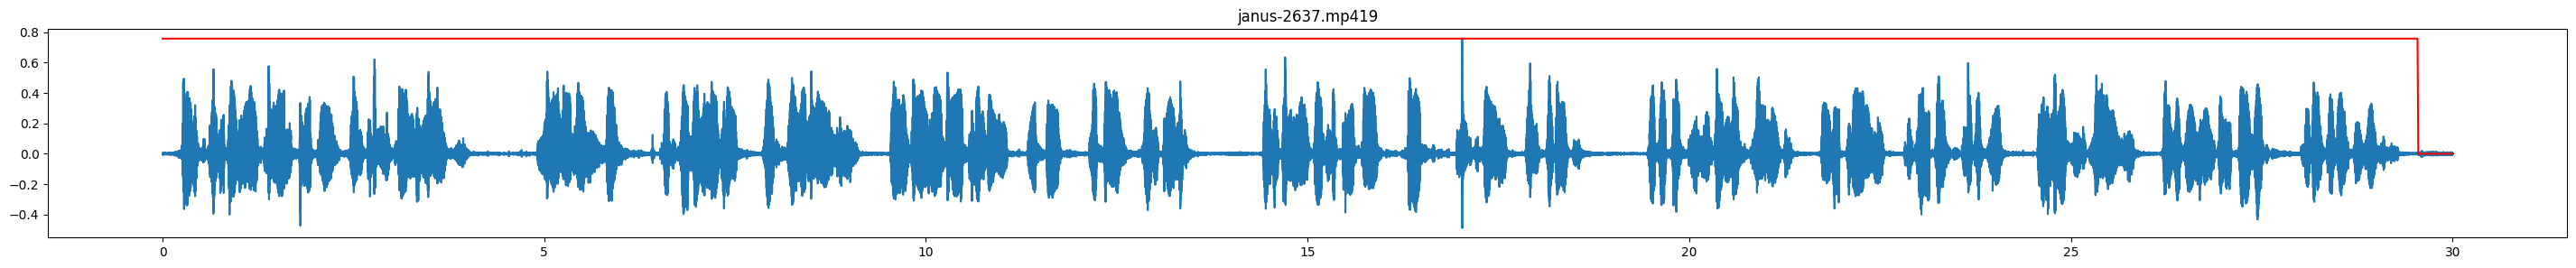

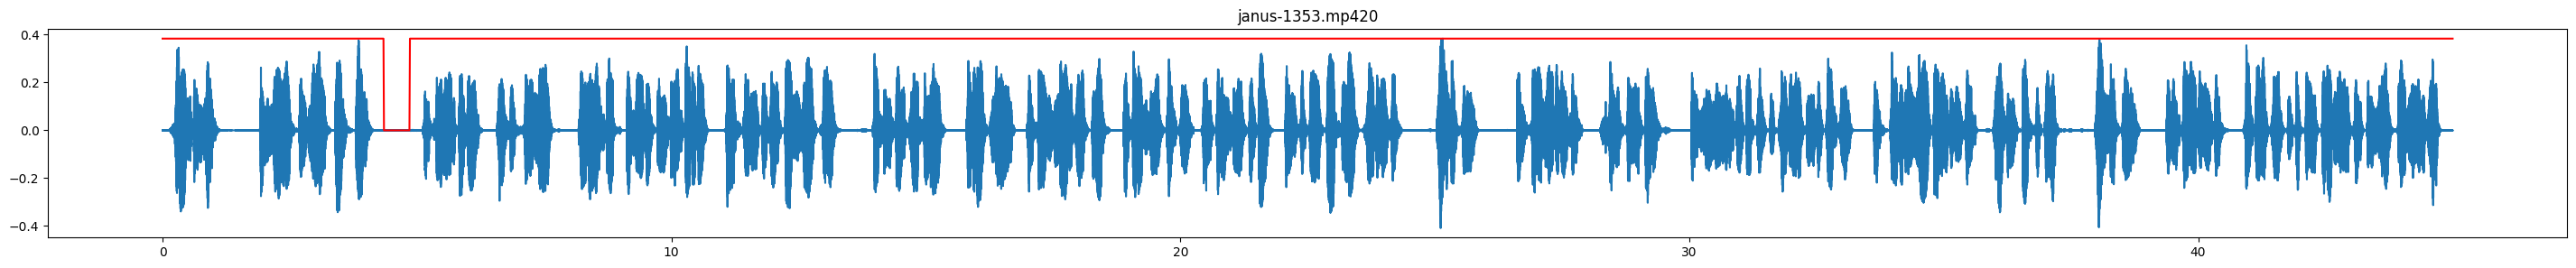

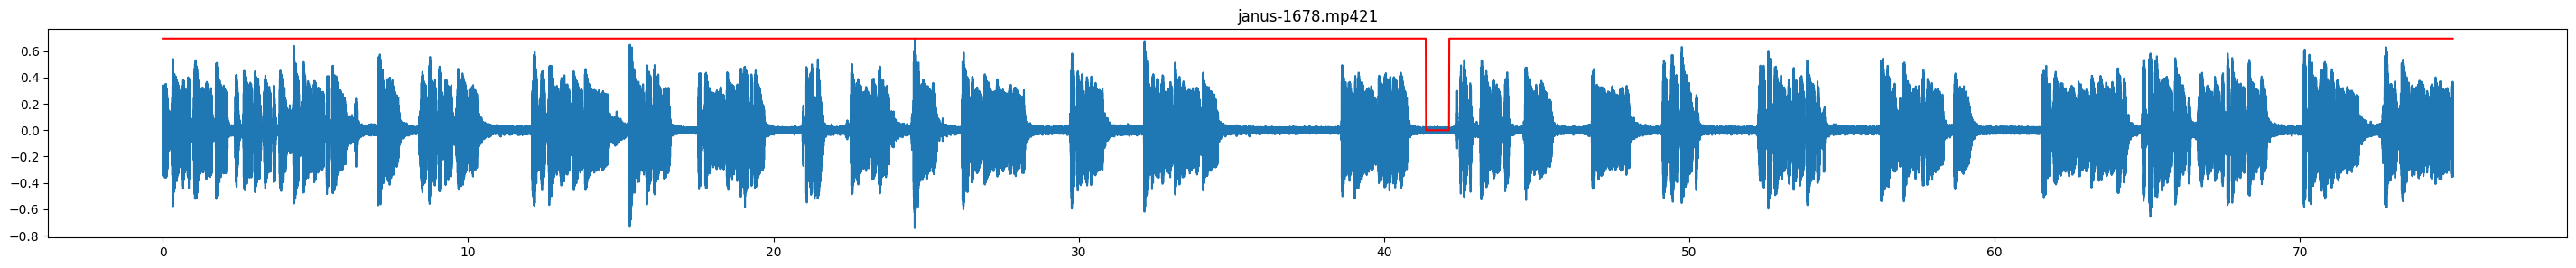

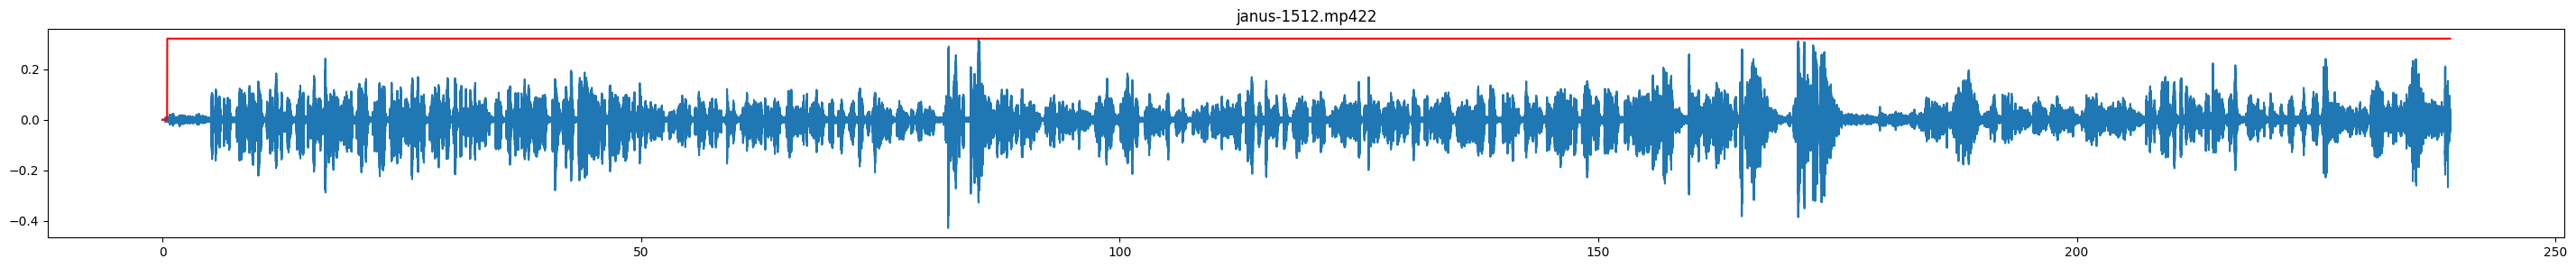

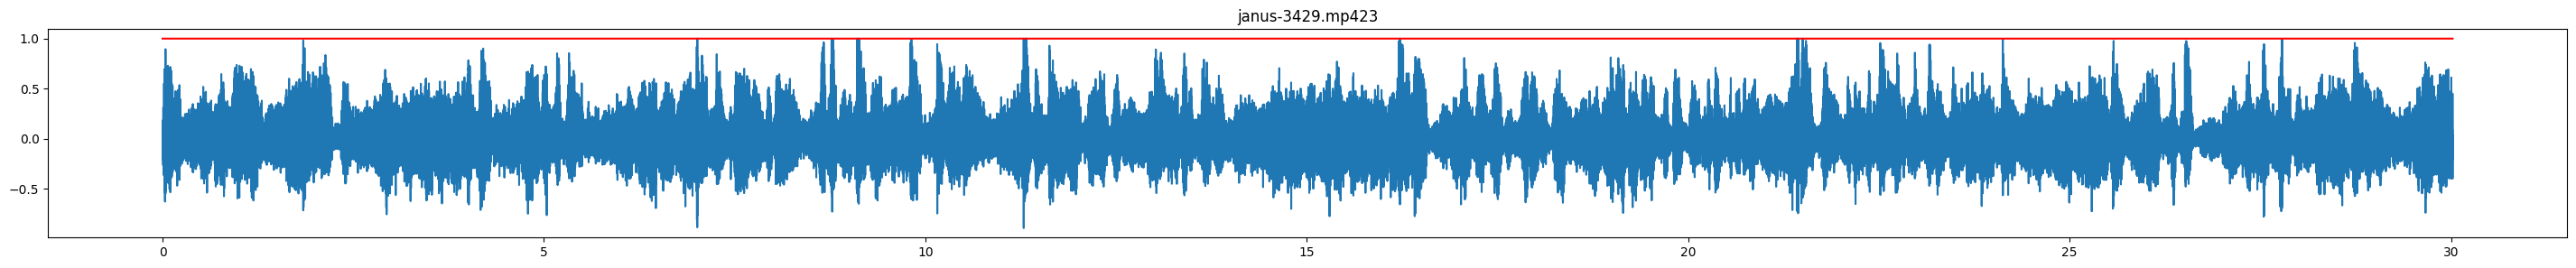

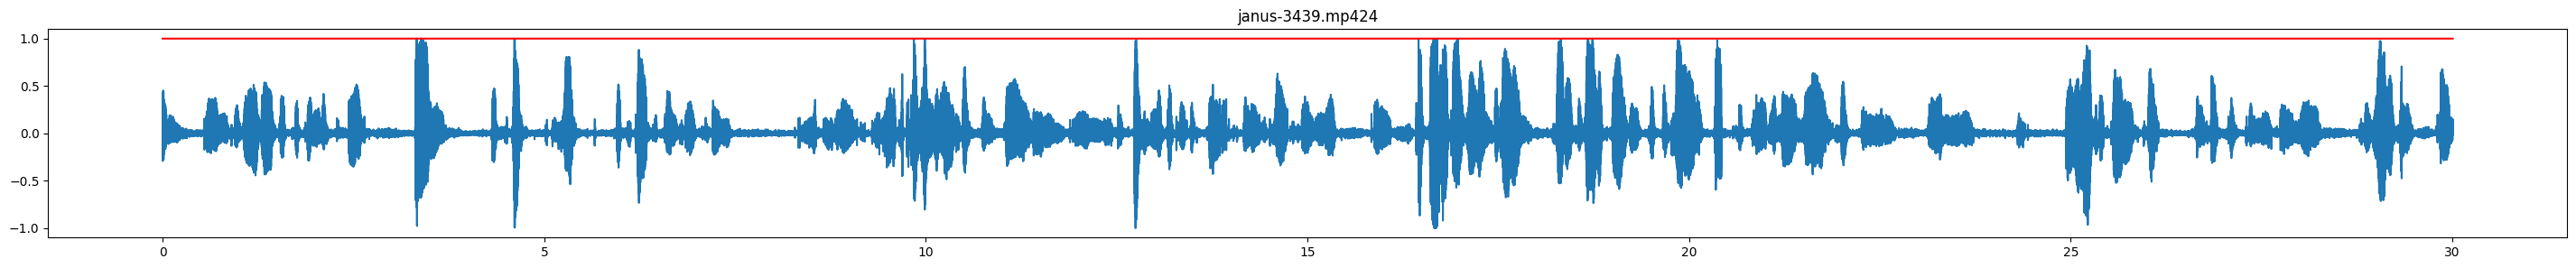

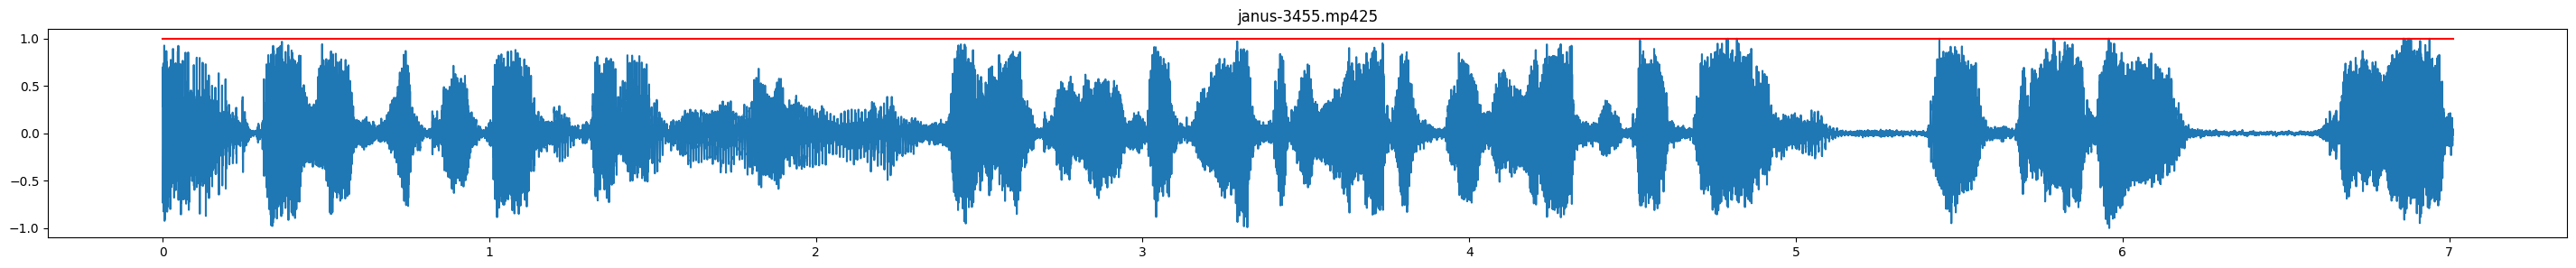

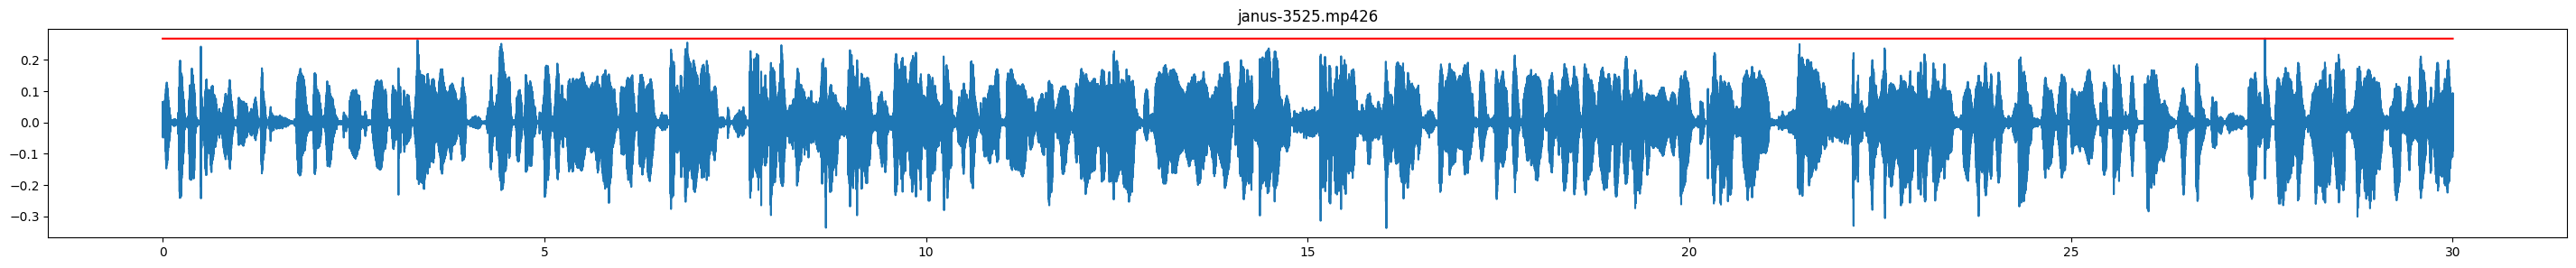

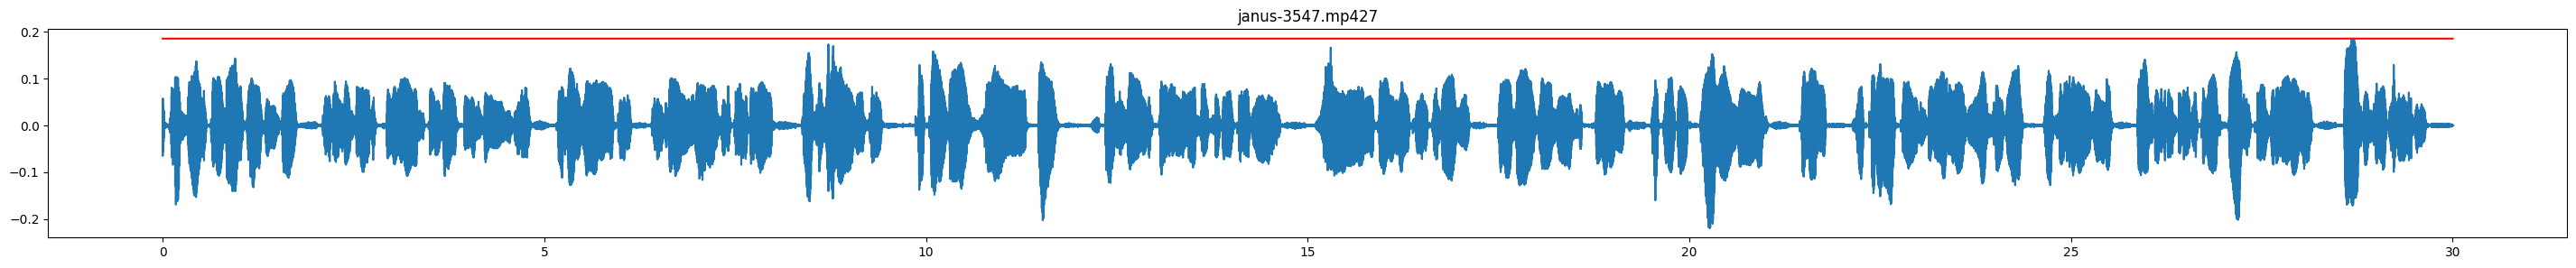

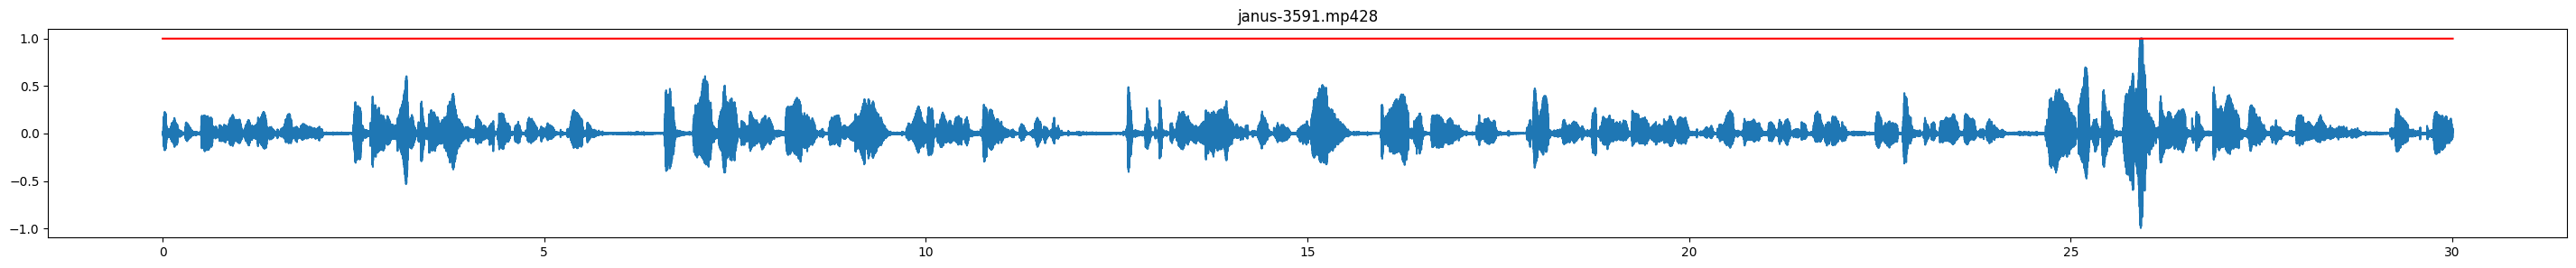

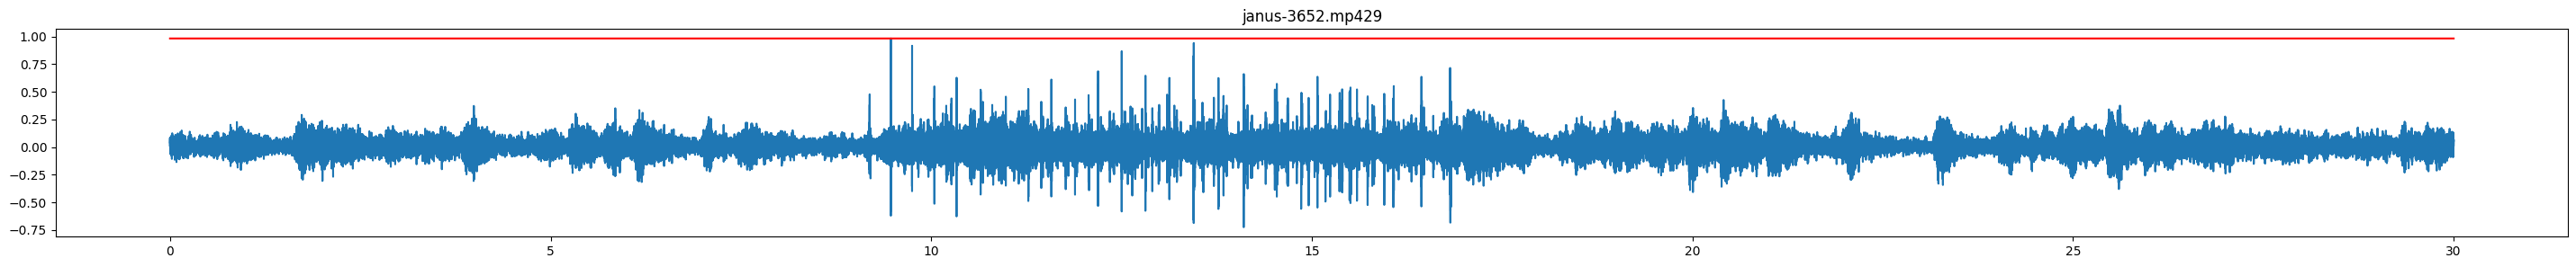

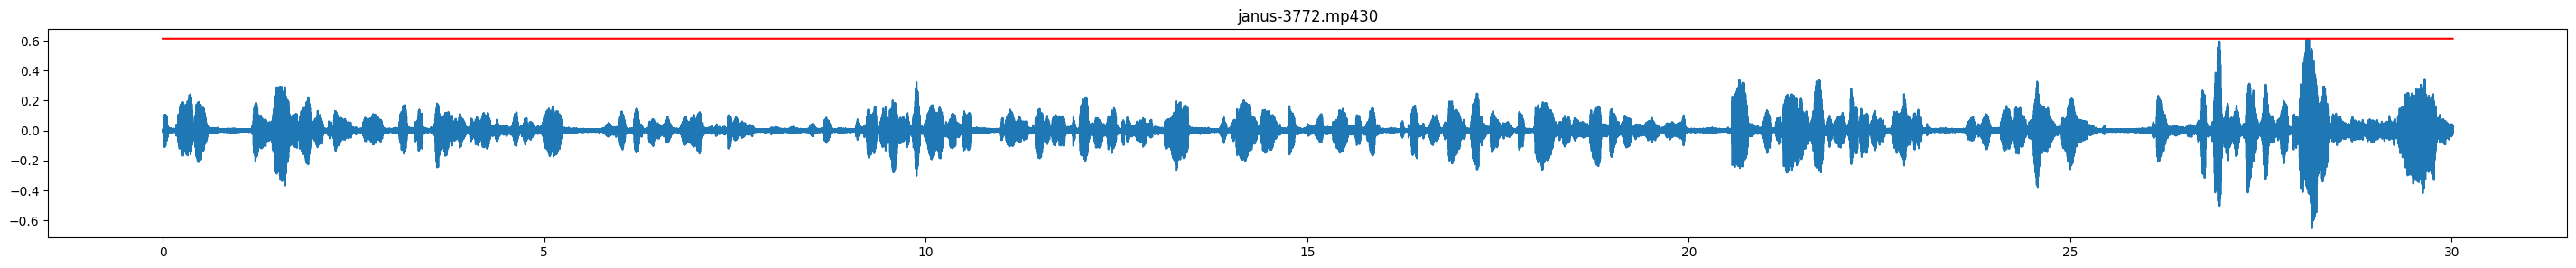

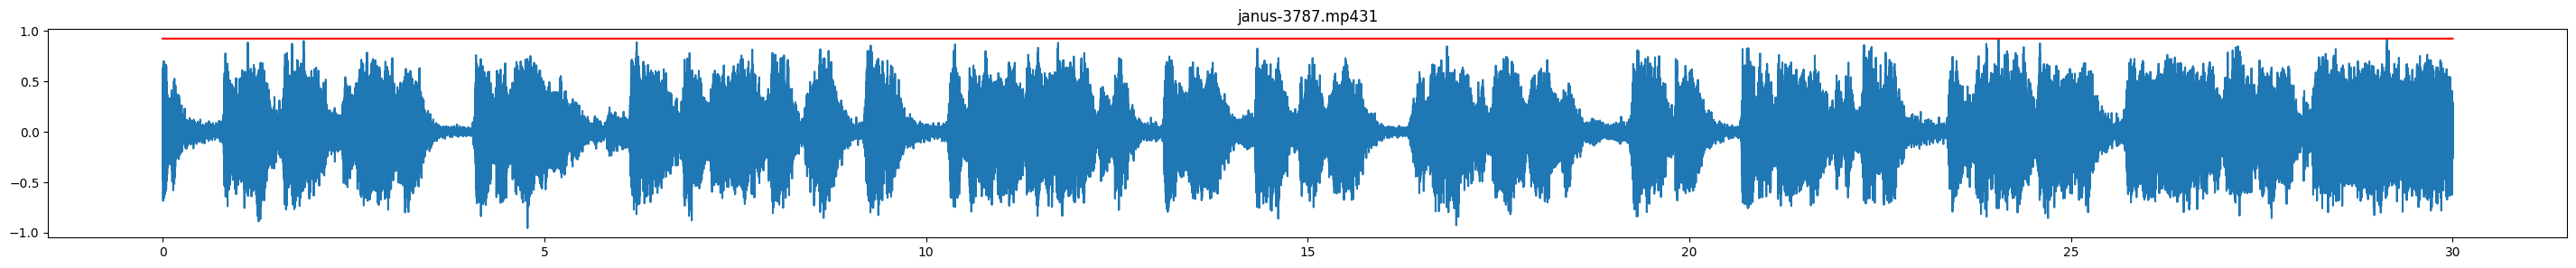

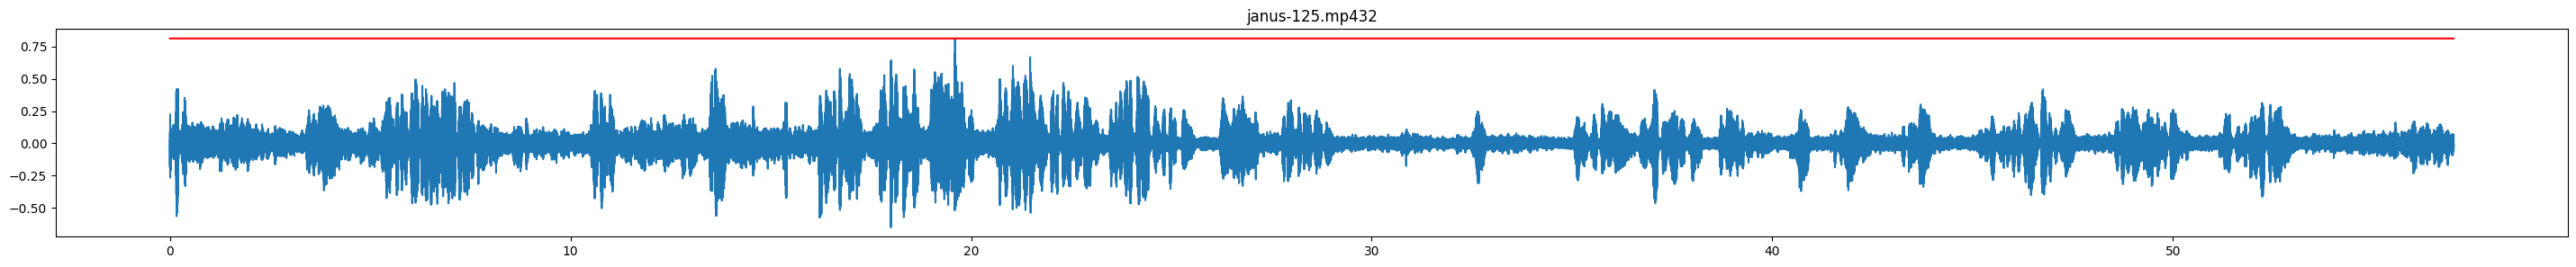

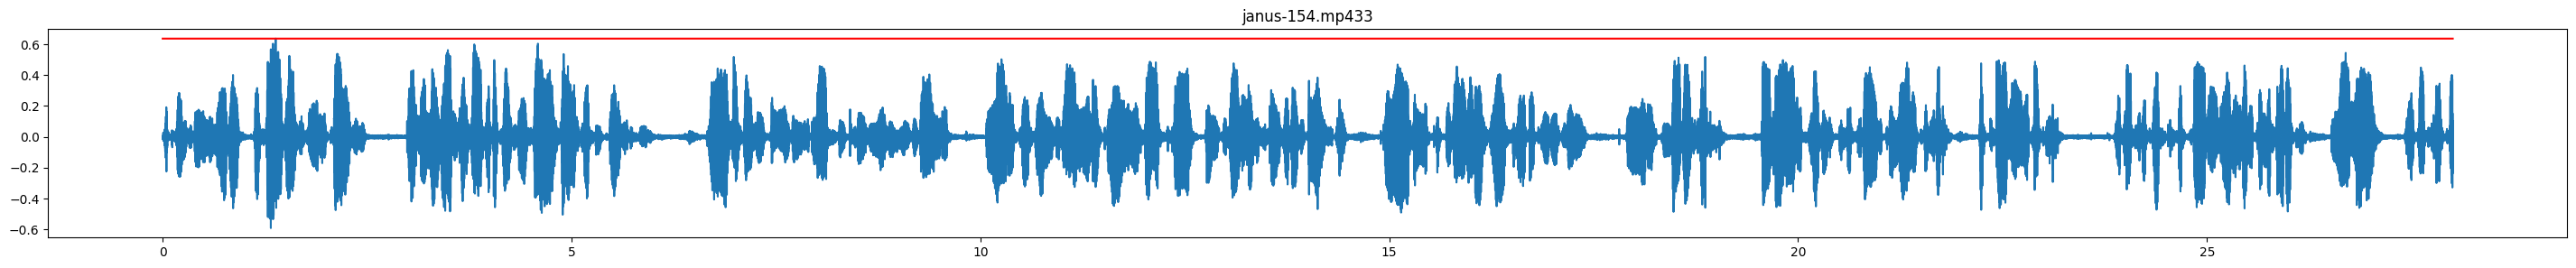

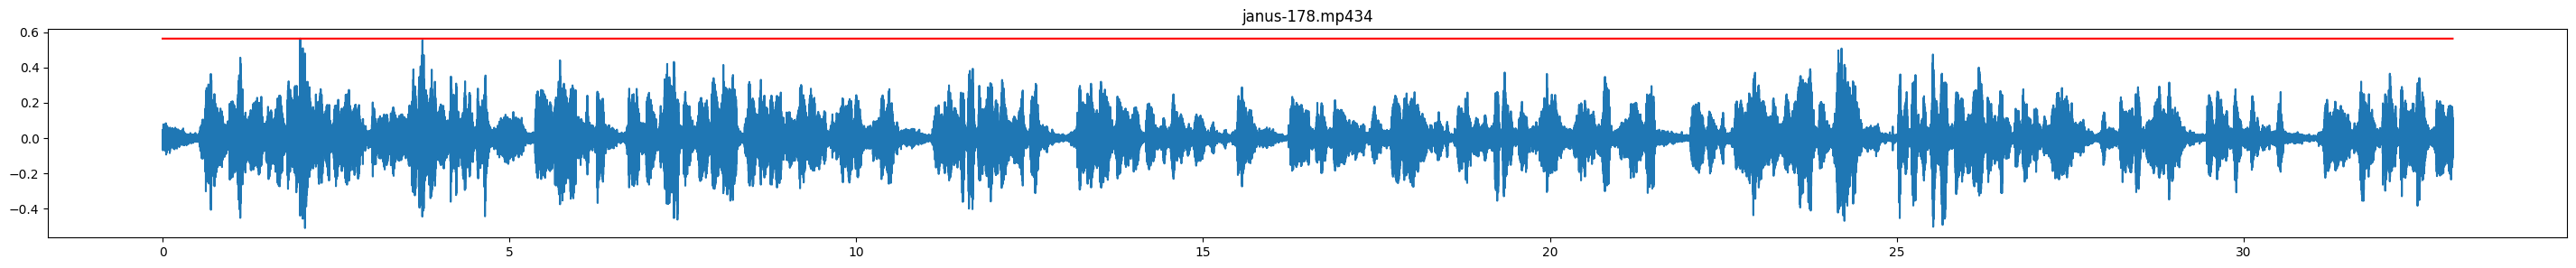

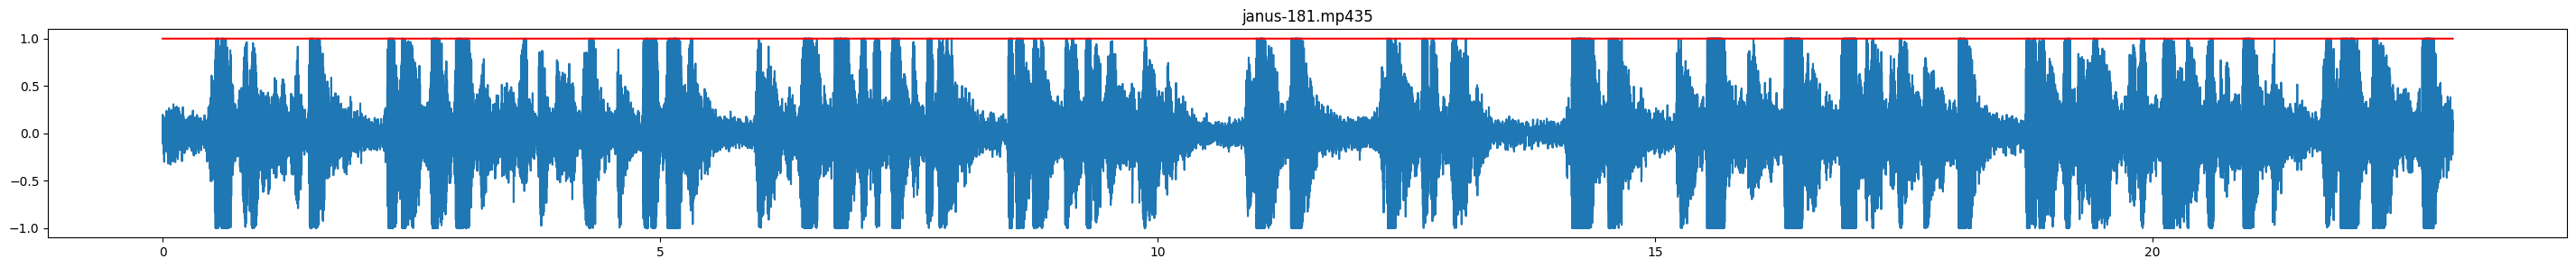

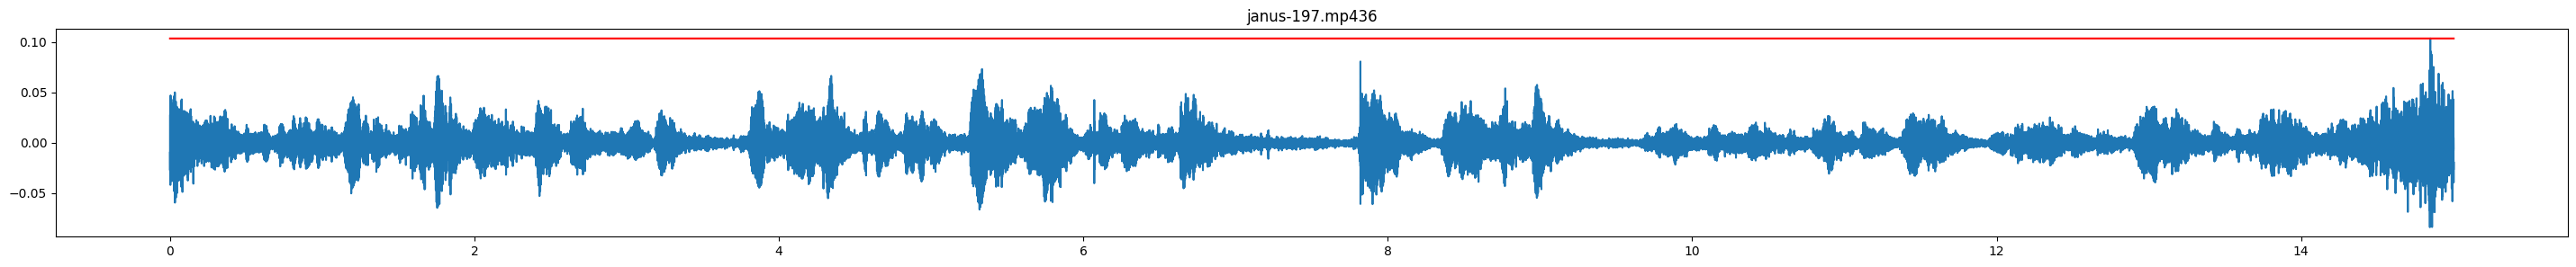

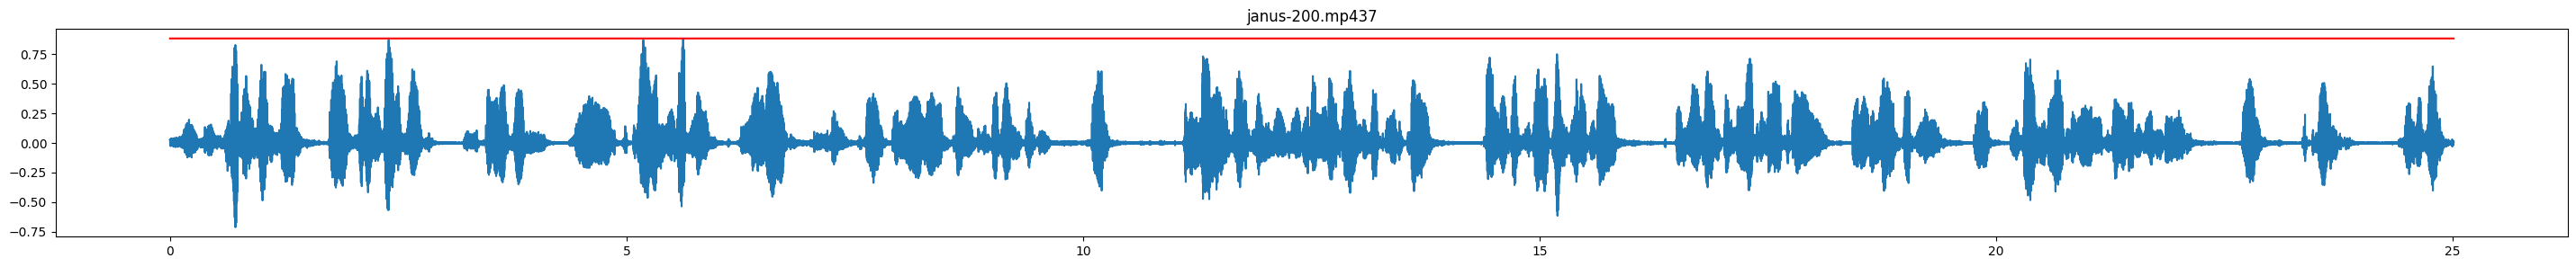

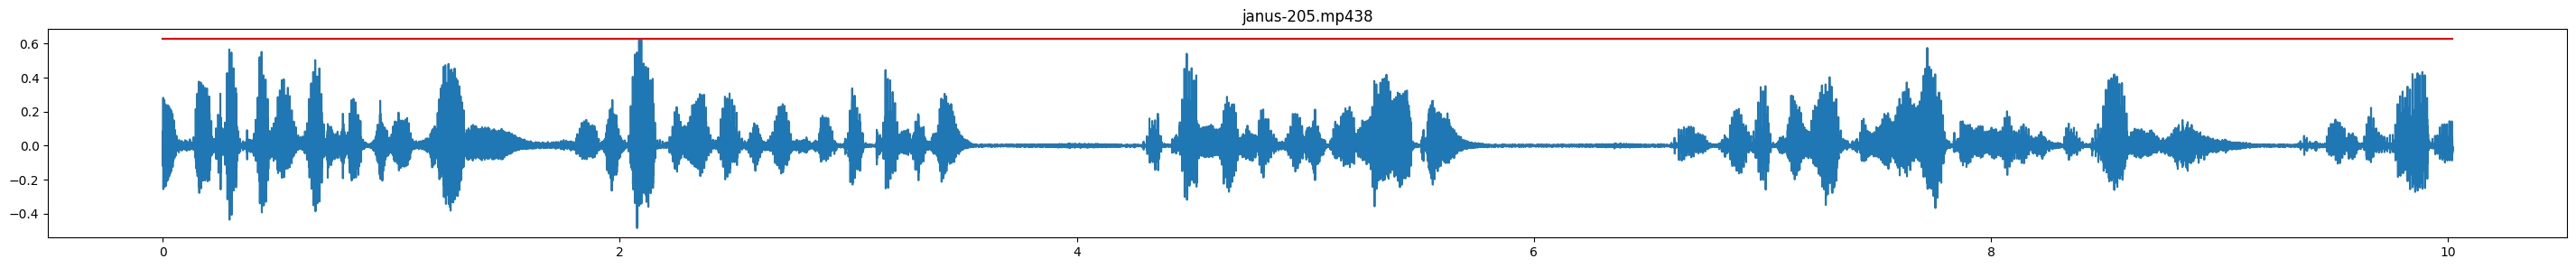

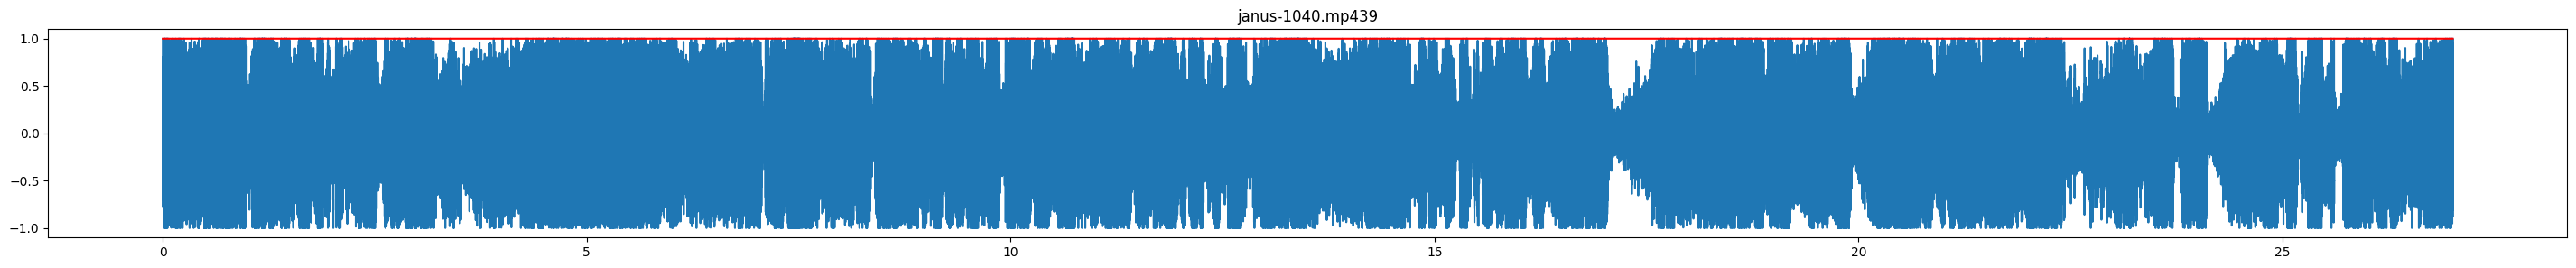

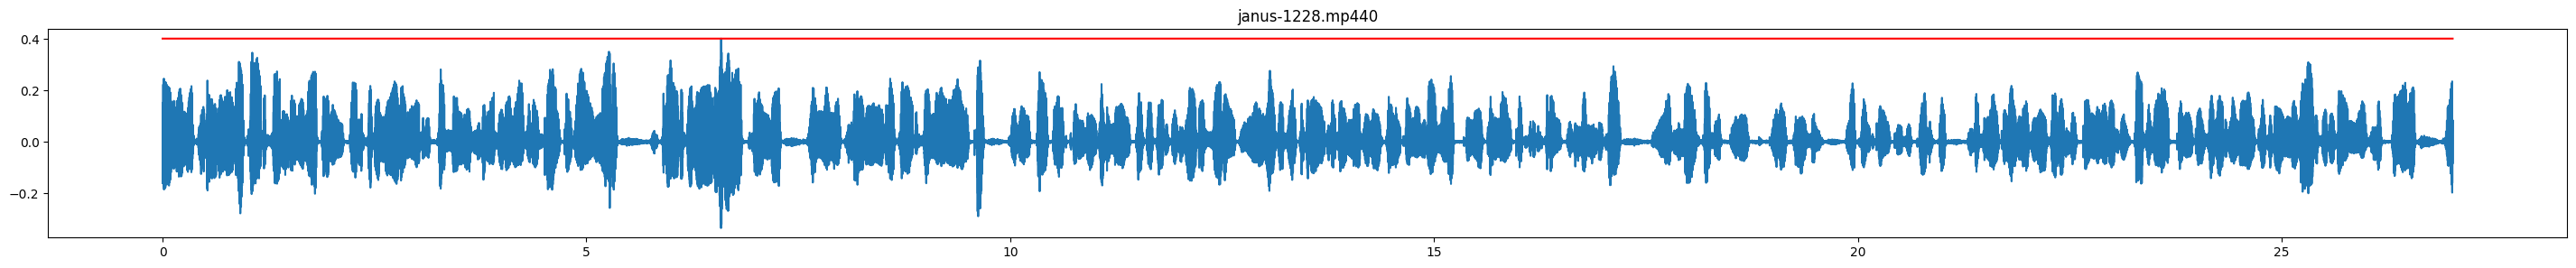

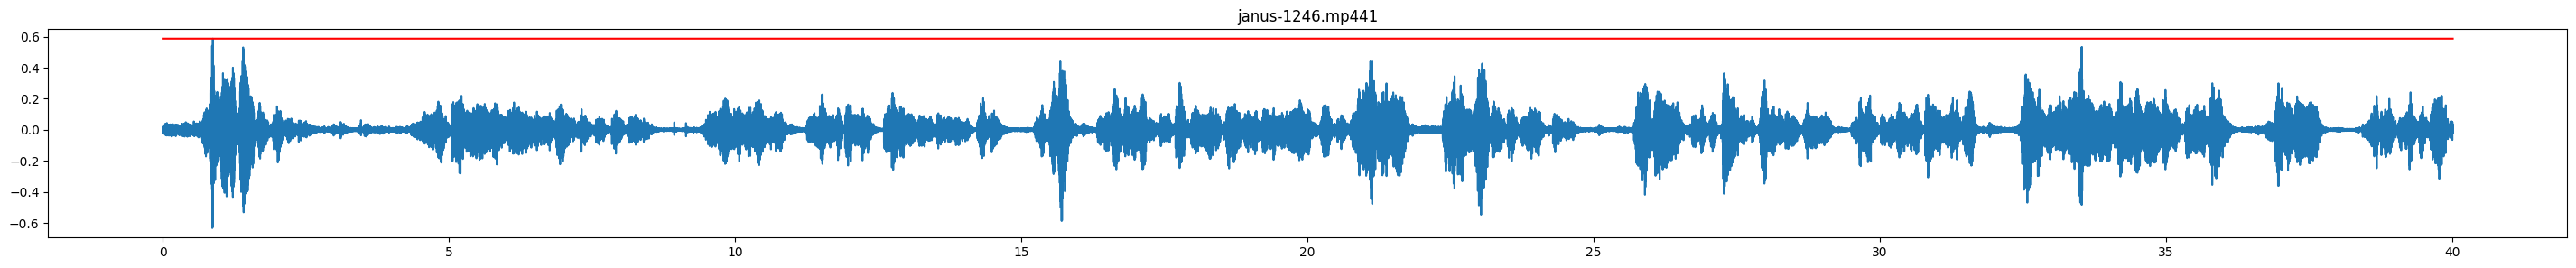

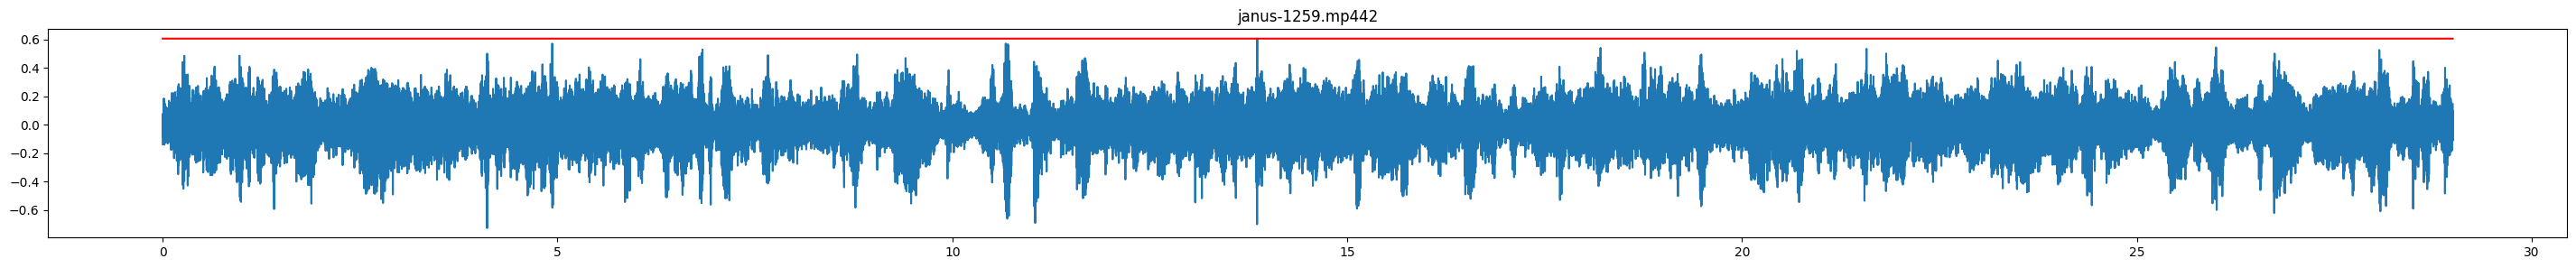

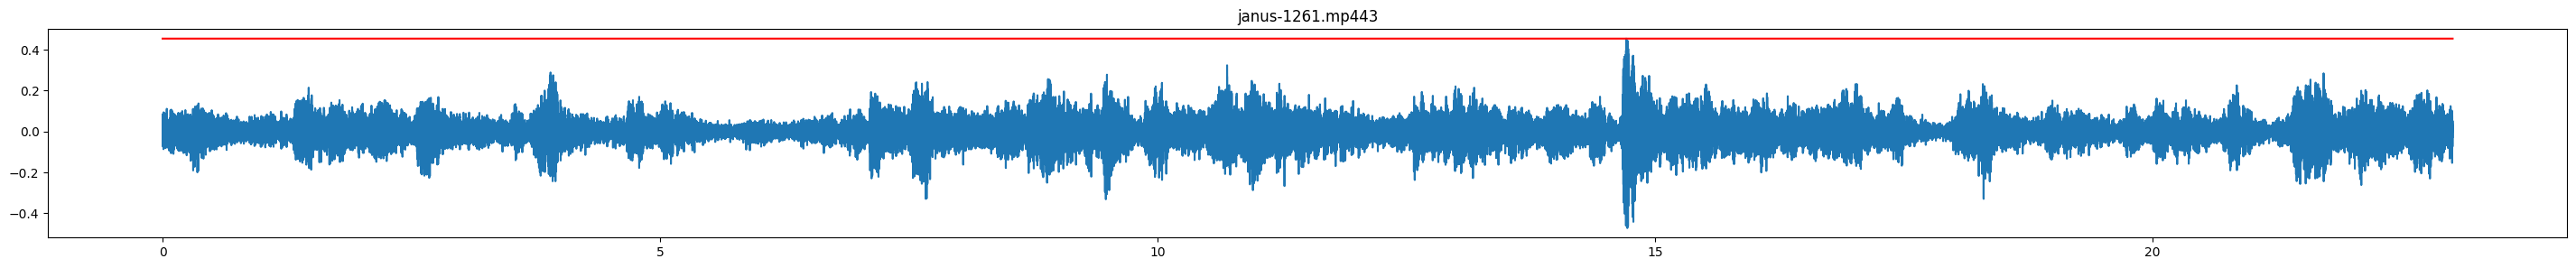

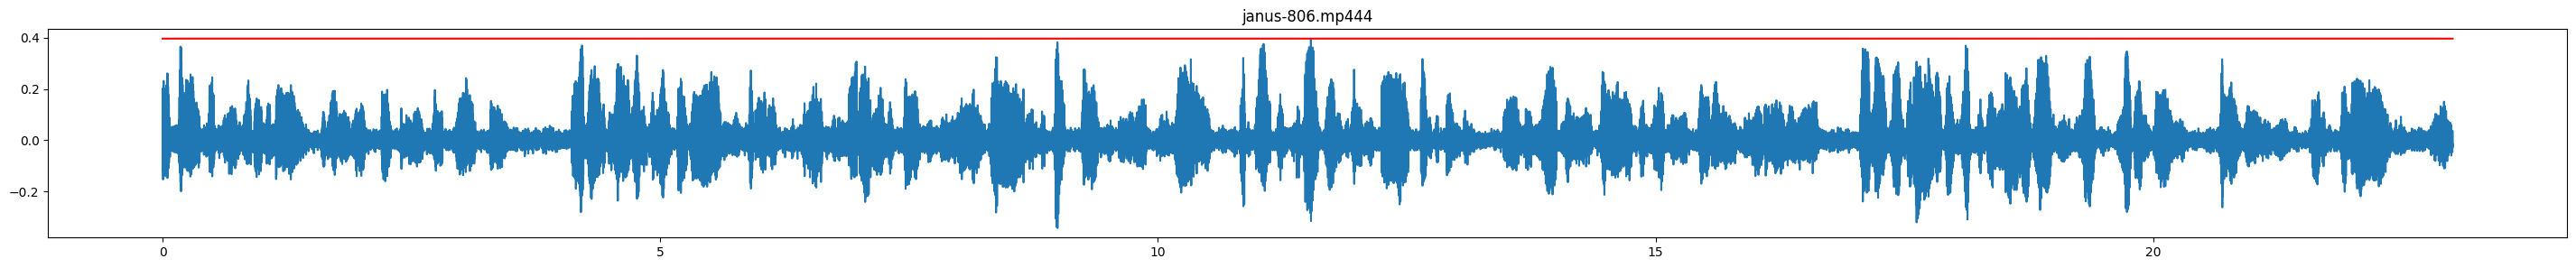

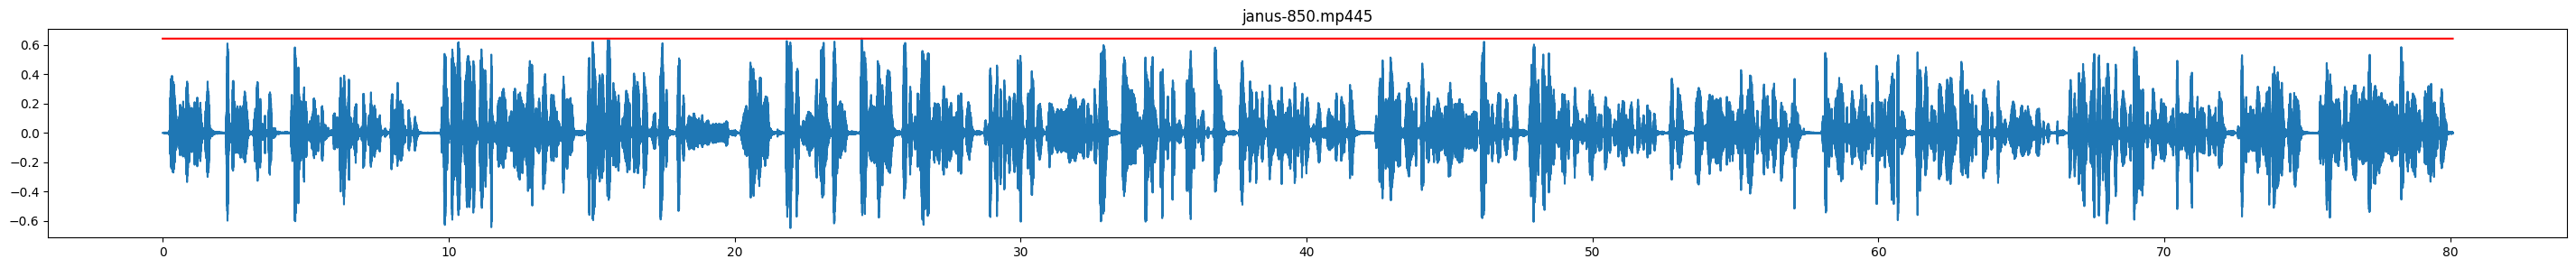

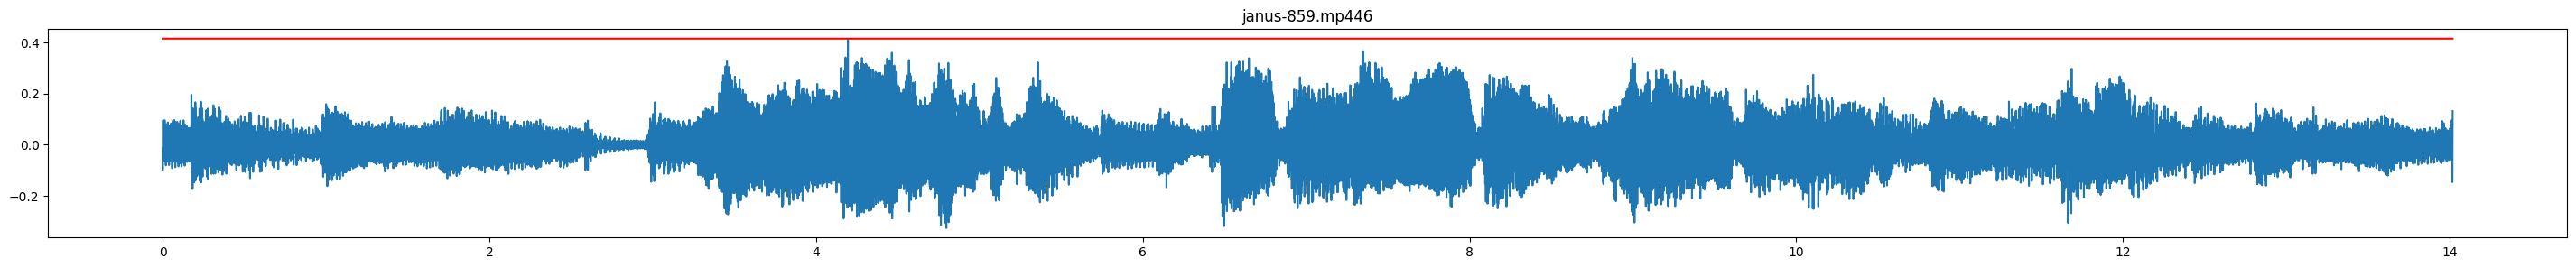

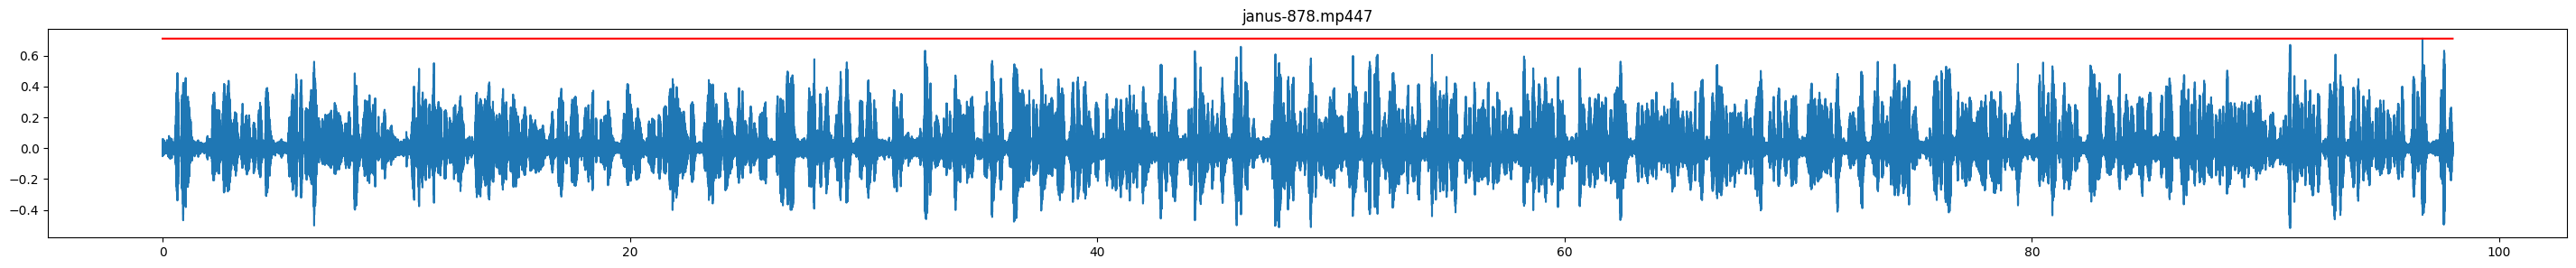

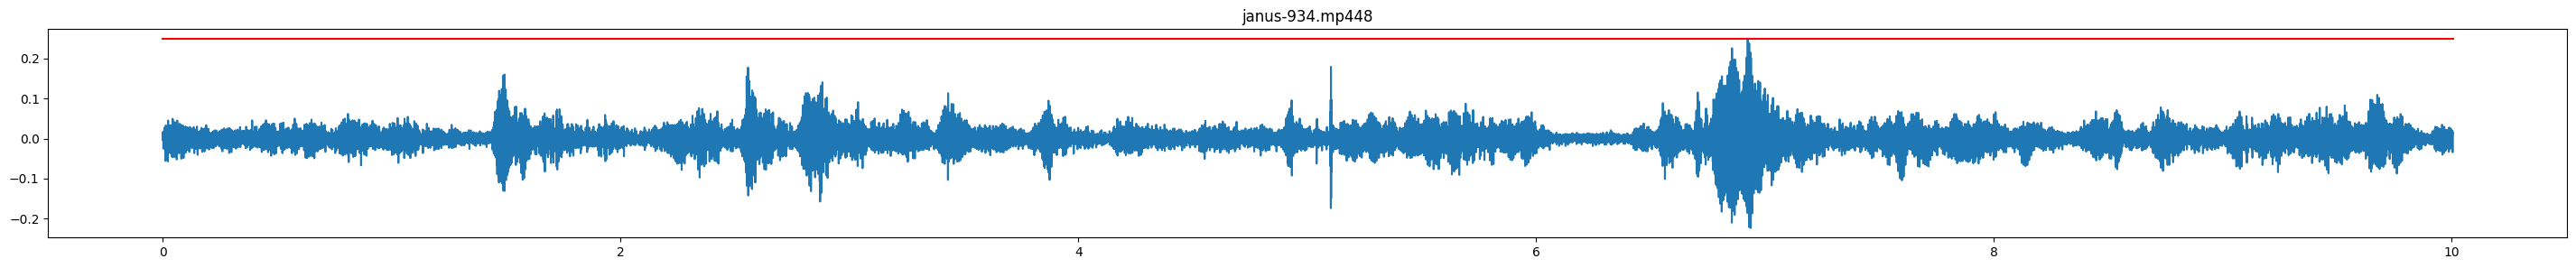

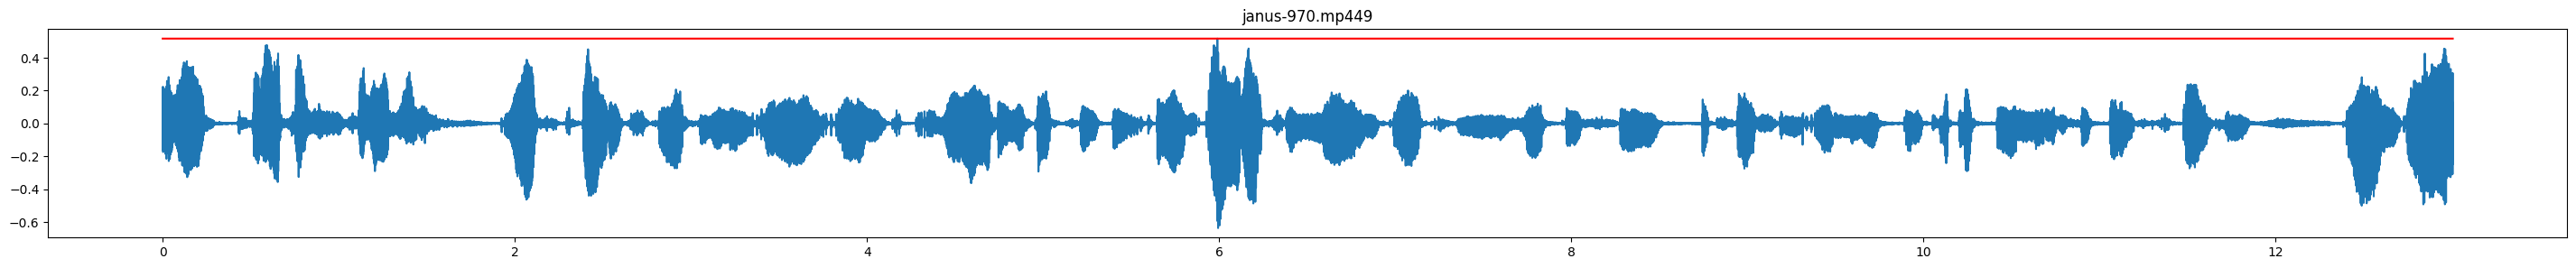

In [81]:
import matplotlib.pyplot as plt
for i in range(len(x)): 
    x_i=x[i]
    v_i = vad[i]
    fs_i=fs[i]
    t=np.linspace(0,len(x_i)/fs_i, len(x_i))
    plt.figure(figsize=(36,3))
    plt.title(keys[i]+str(i))
    plt.plot(t, x_i)
    t=np.linspace(0,len(x_i)/fs_i, len(v_i))
    plt.plot(t, v_i*np.max(x_i), color="r")
    


In [69]:
from IPython.display import Audio
# x_i = x[10]
# fs_i = fs[10]
# Audio(x_i[160*fs_i:240*fs_i], rate=fs_i)
# x_i = x[1]
# fs_i = fs[1]
# Audio(x_i[50*fs_i:60*fs_i], rate=fs_i)
# x_i = x[3]
# fs_i = fs[3]
# Audio(x_i[10*fs_i:50*fs_i], rate=fs_i)
# x_i = x[7]
# fs_i = fs[7]
# Audio(x_i[10*fs_i:30*fs_i], rate=fs_i)
# x_i = x[16]
# fs_i = fs[16]
# Audio(x_i[22*fs_i:40*fs_i], rate=fs_i)
# x_i = x[12]
# fs_i = fs[12]
# Audio(x_i[25*fs_i:75*fs_i], rate=fs_i)
x_i = x[15]
fs_i = fs[6]
Audio(x_i, rate=fs_i)

In [ ]:
# with np.printoptions(threshold=np.inf):
#     print(vad[3])
i=11
x_i = x[i]
fs_i = fs[i]
x_i = x_i-x_i.mean() + np.random.rand(len(x_i)) * 1/2**15
from hyperion.np.feats import st_logE
e =  st_logE(x_i, int(0.025*fs_i), int(0.01*fs_i))
thr = -4.89 + 0.5*np.mean(e[e>np.max(e)-12.5])
thr = -3.5 + 0.5*np.mean(e[e>np.max(e)-12.5])
v_i = e > thr
print(thr)
t=np.linspace(0,len(x_i)/fs_i, len(x_i))
plt.figure(figsize=(36,6))
plt.title(keys[i]+str(i))
plt.plot(t, x_i)
t=np.linspace(0,len(x_i)/fs_i, len(v_i))
plt.plot(t, v_i*np.max(x_i), color="r")
plt.grid()
plt.figure(figsize=(36,6))
plt.plot(t, e, color="g")
plt.grid()


In [ ]:
np.max(e)
# with np.printoptions(threshold=np.inf):
#     print(e)
np.log(200*(10/2**15)**2)


In [ ]:
i=7
x_i = x[i]*2**15
fs_i = fs[i]
x_i = x_i-x_i.mean() #+ 10*np.random.rand(len(x_i))
from hyperion.np.feats import st_logE
e =  st_logE(x_i, int(0.025*fs_i), int(0.01*fs_i))
thr = 5.5 + 0.5*np.mean(e[e>np.max(e)-12.5])
thr = 5.8 + 0.5*np.mean(e[e>np.max(e)-12.5])
v_i = e > thr
print(thr)
t=np.linspace(0,len(x_i)/fs_i, len(x_i))
plt.figure(figsize=(36,6))
plt.title(keys[i]+str(i))
plt.plot(t, x_i)
t=np.linspace(0,len(x_i)/fs_i, len(v_i))
plt.plot(t, v_i*np.max(x_i), color="r")
plt.grid()
plt.figure(figsize=(36,6))
plt.plot(t, e, color="g")
plt.grid()

In [ ]:
print(5.5-15*np.log(2))
100/2**15
print((30*np.log(10)/10+np.log(400)))
np.log(2**30*400)

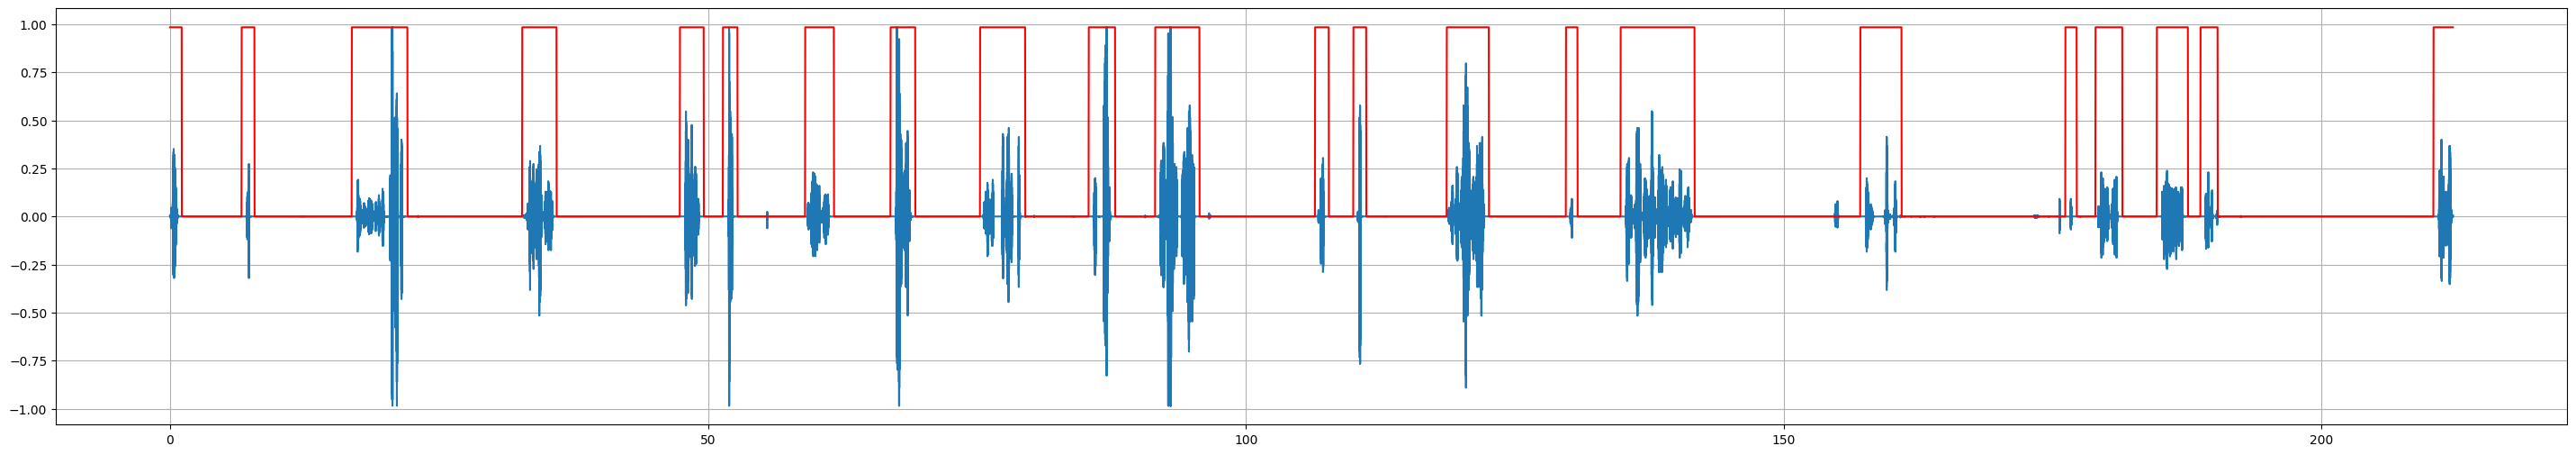

In [51]:
# import matplotlib.pyplot as plt
# from hyperion.np.feats import EnergyVAD
evad = EnergyVAD(sample_frequency=16000, frame_shift=10, frame_length=25, snip_edges=False, 
vad_energy_threshold= -1, vad_energy_mean_scale= 0.5, vad_proportion_threshold= 0.4, 
vad_frames_context= 2, vad_dilation= 0.5, vad_erosion= 0.25)
i = 25
x_i = x[i]
fs_i = fs[i]
v_i = evad.compute(x_i)
t=np.linspace(0,len(x_i)/fs_i, len(x_i))
plt.figure(figsize=(36,6))
plt.plot(t, x_i)
t=np.linspace(0,len(x_i)/fs_i, len(v_i))
plt.plot(t, v_i*np.max(x_i), color="r")
plt.grid()


In [13]:
print(v_i)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True False False False False False False False  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  T